# Dataset overview

Most of these are DHS (Demographic and Health Survey) variables.

Variable	                                                   Meaning
HV001	                                         Cluster number (Enumeration Area)
HV002	                                         Household number
person_no	                                     Child's line number within household
age	                                             Child's age category (usually under-five age groups)
slept_under_treated_net	                         Child slept under an insecticide-treated net last night (0=No, 1=Yes)
slept_under_llin	                             Child slept under Long-Lasting Insecticidal Net (0=No, 1=Yes)
survey_year	                                     DHS survey year
malaria_positive	                             Final malaria status (target variable)
HV206	                                         Electricity in household
HV207	                                         Radio ownership
HV208	                                         Television ownership
HV209	                                         Refrigerator ownership
HV216	                                         Number of sleeping rooms
HV219	                                         Sex of household head
HV220	                                         Age of household head
HV271	                                         Household wealth index score (continuous)
HV201	                                         Source of drinking water
HV205	                                         Type of toilet facility
HV226	                                         Type of cooking fuel
HML1	                                         Fever in the last two weeks
HV270	                                         Wealth index category
HV024	                                         State or region
HV025	                                         Place of residence (Urban/Rural)
avg_temperature	                                 Average temperature
relative_humidity	                             Relative humidity
wind_speed	                                     Average wind speed
precipitation	                                 Rainfall
max_temperature	                                 Maximum temperature
min_temperature	                                 Minimum temperature


My Final Predictor Set

I would keep:

Demographic
age
sex of household head (HV219)
age of household head (HV220)

Household Characteristics
electricity
radio
television
refrigerator
sleeping rooms
drinking water
toilet type
cooking fuel
wealth index
urban/rural residence

Prevention Variables
slept_under_treated_net
slept_under_llin

Geography Variables
state
survey_year

Climate Variables
avg_temperature
relative_humidity
wind_speed
precipitation
max_temperature
min_temperature

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
# Loading the dataset
df = pd.read_csv('final_model_data.csv')

In [3]:
df.head()

,HHID,HV001,HV002,person_no,age,slept_under_treated_net,slept_under_llin,blood_smear_result,rapid_test_result,pfalciparum,pmalariae,survey_year,malaria_positive,HV005,HV206,HV207,HV208,HV209,HV216,HV219,HV220,HV271,HV201,HV205,HV226,HML1,HV270,HV024,HV025,state,avg_temperature,relative_humidity,wind_speed,precipitation,max_temperature,min_temperature
0,2 23,2,23,2,3,0,0,1,1,1,0,2010,1,937436,0,1,1,0,10,2,23,-51978,32,22,8,0,3,1,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
1,2 24,2,24,2,4,1,1,1,1,1,0,2010,1,937436,0,1,0,0,3,2,27,-94706,32,31,8,1,2,1,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
2,4 3,4,3,2,4,0,0,1,1,1,0,2010,1,1587863,0,1,0,0,4,1,35,-108517,31,31,8,0,2,1,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
3,4 20,4,20,2,2,0,0,1,1,1,0,2010,1,1587863,1,0,0,0,2,1,18,-107283,43,31,8,0,2,1,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3
4,6 7,6,7,2,1,0,0,0,0,0,0,2010,0,1195312,0,0,0,0,1,2,35,-98578,43,43,8,0,2,1,2,Sokoto,27.82,46.76,3.43,1.94,44.94,11.3


In [38]:
df.tail()

,age,slept_under_treated_net,slept_under_llin,survey_year,malaria_positive,HV206,HV207,HV208,HV209,HV216,HV219,HV220,HV271,HV201,HV205,HV226,HML1,HV270,HV024,HV025,state,avg_temperature,relative_humidity,wind_speed,precipitation,max_temperature,min_temperature
21540,4,0,0,2021,0,1,1,1,1,16,1,50,65481,32,22,13,0,4,11,1,Kaduna,23.36,70.17,3.33,17.43,38.28,10.52
21541,3,0,0,2021,0,0,1,0,0,14,1,56,-109306,42,31,11,7,2,17,2,Taraba,26.90,61.70,3.33,2.73,42.28,14.29
21542,4,0,0,2021,0,0,1,0,0,14,1,56,-109306,42,31,11,7,2,17,2,Taraba,26.90,61.70,3.33,2.73,42.28,14.29
21543,4,0,0,2021,0,1,1,1,1,16,1,50,65481,32,22,13,0,4,11,1,Kaduna,23.36,70.17,3.33,17.43,38.28,10.52
21544,0,0,0,2021,0,0,1,0,0,14,1,56,-109306,42,31,11,7,2,17,2,Taraba,26.90,61.70,3.33,2.73,42.28,14.29


In [4]:
df.shape

(21545, 36)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21545 entries, 0 to 21544
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      21545 non-null  int64  
 1   slept_under_treated_net  21545 non-null  int64  
 2   slept_under_llin         21545 non-null  int64  
 3   survey_year              21545 non-null  int64  
 4   malaria_positive         21545 non-null  int64  
 5   HV206                    21545 non-null  int64  
 6   HV207                    21545 non-null  int64  
 7   HV208                    21545 non-null  int64  
 8   HV209                    21545 non-null  int64  
 9   HV216                    21545 non-null  int64  
 10  HV219                    21545 non-null  int64  
 11  HV220                    21545 non-null  int64  
 12  HV271                    21545 non-null  int64  
 13  HV201                    21545 non-null  int64  
 14  HV205                 

One Area That Raises Concern 

Is:

blood_smear_result
rapid_test_result
pfalciparum
pmalariae
malaria_positive

These variables are almost certainly derived from the malaria test itself.

For example:

Observation 1:

blood_smear_result = 1
rapid_test_result = 1
pfalciparum = 1
malaria_positive = 1

Observation 5:

blood_smear_result = 0
rapid_test_result = 0
pfalciparum = 0
malaria_positive = 0

This is a huge red flag.

Data Leakage Warning

Since the goal is to Predict whether a child has malaria

then using:

blood_smear_result
rapid_test_result
pfalciparum
pmalariae

is cheating.

These variables already tell us whether the child has malaria.

Therefore, the model will achieve:

Accuracy: ~99%
AUC: ~1.00

but the model would be useless in real life.

Therefore, it would be adiviced to REMOVE these variables and leave only malaria positive:

In [18]:
# Create Proper Variable Groups

# Target Variable
target = 'malaria_positive'

# Numerical Variables
num_cols = [
    'HV220',
    'HV271',
    'avg_temperature',
    'relative_humidity',
    'wind_speed',
    'precipitation',
    'max_temperature',
    'min_temperature'
]

# Categorical Variables
cat_cols = [
    'age',
    'slept_under_treated_net',
    'slept_under_llin',
    'survey_year',
    'HV206',
    'HV207',
    'HV208',
    'HV209',
    'HV216',
    'HV219',
    'HV201',
    'HV205',
    'HV226',
    'HML1',
    'HV270',
    'HV024',
    'HV025',
    'state'
]

In [5]:
# To drop them
leakage_cols = [
    'blood_smear_result',
    'rapid_test_result',
    'pfalciparum',
    'pmalariae'
]

df = df.drop(columns=leakage_cols)

In [6]:
# Drop these too
Excess_ID = ['HHID',
'HV001',
'HV002',
'person_no',
'HV005'
]

df = df.drop(columns=Excess_ID)

In [7]:
# Statistical summary
df.describe()

,age,slept_under_treated_net,slept_under_llin,survey_year,malaria_positive,HV206,HV207,HV208,HV209,HV216,HV219,HV220,HV271,HV201,HV205,HV226,HML1,HV270,HV024,HV025,avg_temperature,relative_humidity,wind_speed,precipitation,max_temperature,min_temperature
count,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000
mean,2.341611,0.183709,0.362497,2016.775122,0.268647,0.438756,0.532421,0.401253,0.188628,2.770712,1.093432,43.885728,-20423.294500,31.061035,22.865769,8.389139,1.683082,2.989696,9.845950,1.698724,26.508537,55.809301,3.195428,3.922908,41.248265,11.174587
std,1.316681,0.387255,0.480732,4.540302,0.443266,0.496247,0.498959,0.490163,0.391222,1.852795,0.291044,14.224868,94763.450259,15.209541,7.962272,3.266731,1.764364,1.384656,10.161104,0.458823,1.119017,16.151890,0.638484,3.274037,3.774415,3.814709
min,0.000000,0.000000,0.000000,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000,-218760.000000,11.000000,11.000000,1.000000,0.000000,1.000000,1.000000,1.000000,22.420000,35.000000,1.630000,1.020000,31.860000,5.360000
25%,1.000000,0.000000,0.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,35.000000,-99680.000000,21.000000,21.000000,8.000000,0.000000,2.000000,3.000000,1.000000,25.970000,43.160000,2.580000,1.930000,39.580000,8.610000
50%,2.000000,0.000000,0.000000,2015.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000,40.000000,-39469.000000,31.000000,22.000000,8.000000,1.000000,3.000000,5.000000,2.000000,26.650000,49.510000,3.430000,2.270000,42.790000,10.250000
75%,4.000000,0.000000,1.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,1.000000,50.000000,54451.000000,42.000000,31.000000,11.000000,3.000000,4.000000,15.000000,2.000000,27.280000,64.830000,3.760000,4.890000,43.600000,14.210000
max,5.000000,1.000000,1.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,98.000000,284041.000000,96.000000,96.000000,96.000000,7.000000,5.000000,37.000000,2.000000,28.550000,89.160000,4.040000,17.430000,45.320000,20.830000


In [44]:
df.describe(include='object')

,state
count,21545
unique,37
top,Katsina
freq,3134


In [45]:
# Checking for missing values
df.isnull().sum()

age                        0
slept_under_treated_net    0
slept_under_llin           0
survey_year                0
malaria_positive           0
HV206                      0
HV207                      0
HV208                      0
HV209                      0
HV216                      0
HV219                      0
HV220                      0
HV271                      0
HV201                      0
HV205                      0
HV226                      0
HML1                       0
HV270                      0
HV024                      0
HV025                      0
state                      0
avg_temperature            0
relative_humidity          0
wind_speed                 0
precipitation              0
max_temperature            0
min_temperature            0
dtype: int64

# Duplicate records

In [10]:
df.duplicated().sum()

0

# Descriptive statistics

In [8]:
# Numerical variables
df.describe()

,age,slept_under_treated_net,slept_under_llin,survey_year,malaria_positive,HV206,HV207,HV208,HV209,HV216,HV219,HV220,HV271,HV201,HV205,HV226,HML1,HV270,HV024,HV025,avg_temperature,relative_humidity,wind_speed,precipitation,max_temperature,min_temperature
count,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000,21545.000000
mean,2.341611,0.183709,0.362497,2016.775122,0.268647,0.438756,0.532421,0.401253,0.188628,2.770712,1.093432,43.885728,-20423.294500,31.061035,22.865769,8.389139,1.683082,2.989696,9.845950,1.698724,26.508537,55.809301,3.195428,3.922908,41.248265,11.174587
std,1.316681,0.387255,0.480732,4.540302,0.443266,0.496247,0.498959,0.490163,0.391222,1.852795,0.291044,14.224868,94763.450259,15.209541,7.962272,3.266731,1.764364,1.384656,10.161104,0.458823,1.119017,16.151890,0.638484,3.274037,3.774415,3.814709
min,0.000000,0.000000,0.000000,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000,-218760.000000,11.000000,11.000000,1.000000,0.000000,1.000000,1.000000,1.000000,22.420000,35.000000,1.630000,1.020000,31.860000,5.360000
25%,1.000000,0.000000,0.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,35.000000,-99680.000000,21.000000,21.000000,8.000000,0.000000,2.000000,3.000000,1.000000,25.970000,43.160000,2.580000,1.930000,39.580000,8.610000
50%,2.000000,0.000000,0.000000,2015.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000,40.000000,-39469.000000,31.000000,22.000000,8.000000,1.000000,3.000000,5.000000,2.000000,26.650000,49.510000,3.430000,2.270000,42.790000,10.250000
75%,4.000000,0.000000,1.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,1.000000,50.000000,54451.000000,42.000000,31.000000,11.000000,3.000000,4.000000,15.000000,2.000000,27.280000,64.830000,3.760000,4.890000,43.600000,14.210000
max,5.000000,1.000000,1.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,98.000000,284041.000000,96.000000,96.000000,96.000000,7.000000,5.000000,37.000000,2.000000,28.550000,89.160000,4.040000,17.430000,45.320000,20.830000


In [9]:
# Categorical
df.describe(include='object')

,state
count,21545
unique,37
top,Katsina
freq,3134


In [11]:
# Target Distribution
df['malaria_positive'].value_counts()

malaria_positive
0    15757
1     5788
Name: count, dtype: int64

In [12]:
df['malaria_positive'].value_counts(normalize=True)*100

malaria_positive
0    73.135298
1    26.864702
Name: proportion, dtype: float64

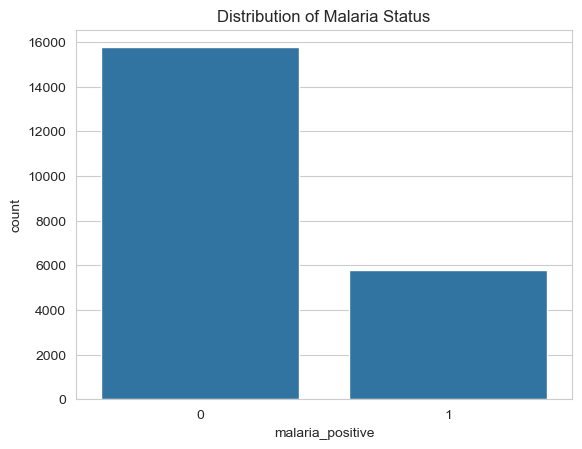

In [13]:
sns.countplot(
    data=df,
    x='malaria_positive'
)

plt.title('Distribution of Malaria Status')
plt.show()

In [48]:
# Separating numerical and categorical variables
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'slept_under_treated_net', 'slept_under_llin', 'survey_year',
       'malaria_positive', 'HV206', 'HV207', 'HV208', 'HV209', 'HV216',
       'HV219', 'HV220', 'HV271', 'HV201', 'HV205', 'HV226', 'HML1', 'HV270',
       'HV024', 'HV025', 'avg_temperature', 'relative_humidity', 'wind_speed',
       'precipitation', 'max_temperature', 'min_temperature'],
      dtype='object')
Index(['state'], dtype='object')


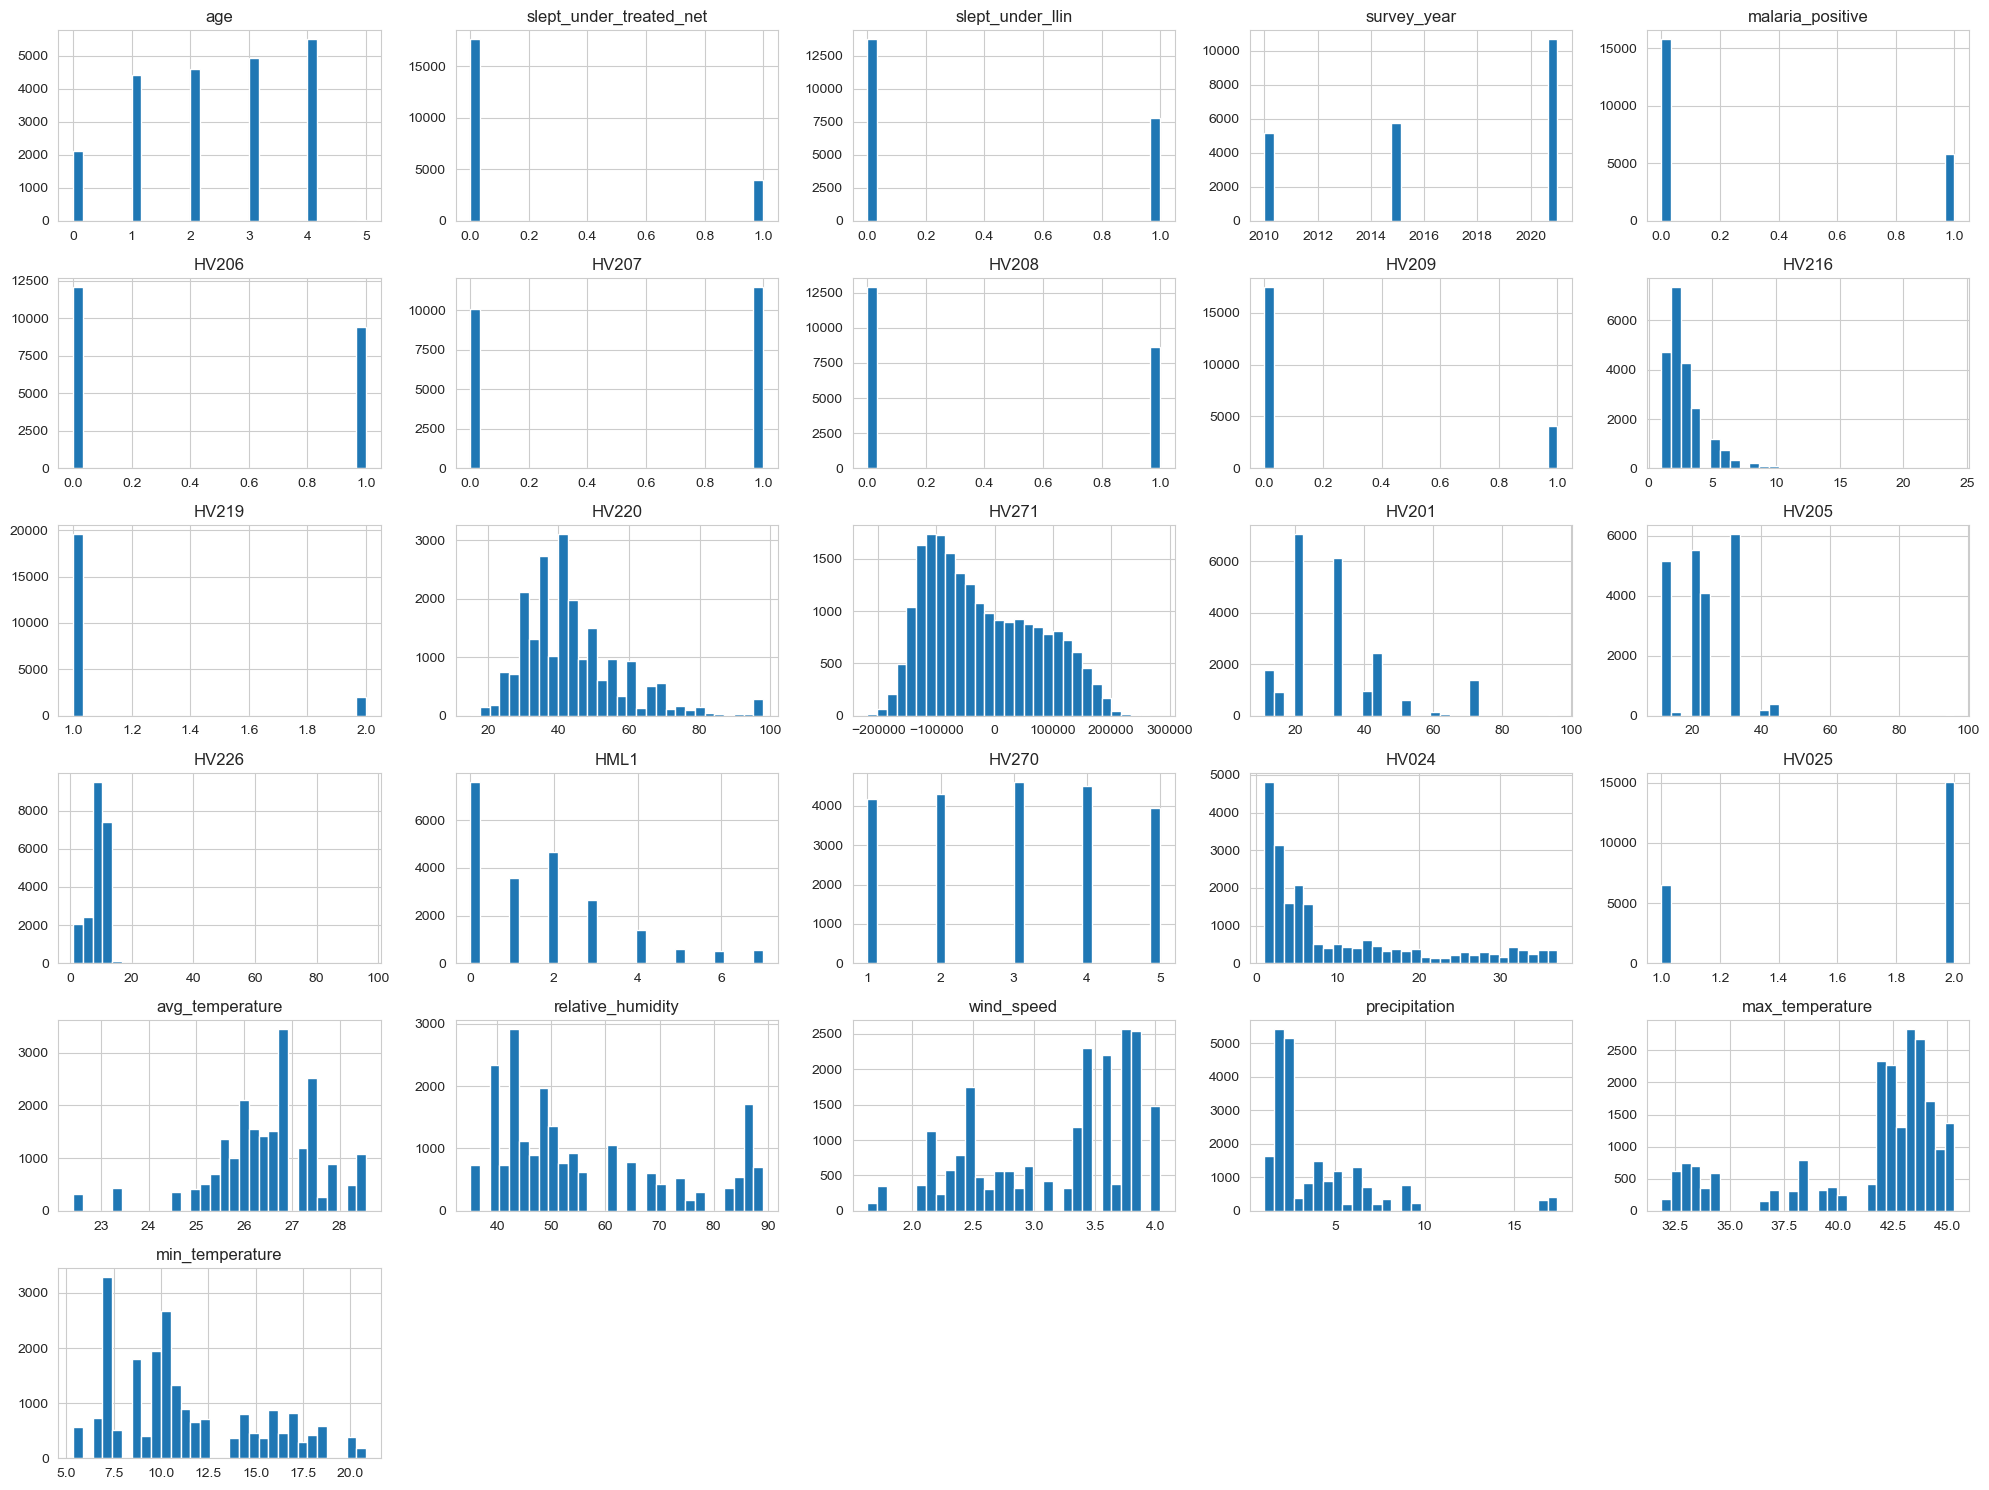

In [49]:
# Distribution of numerical variables

df[num_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

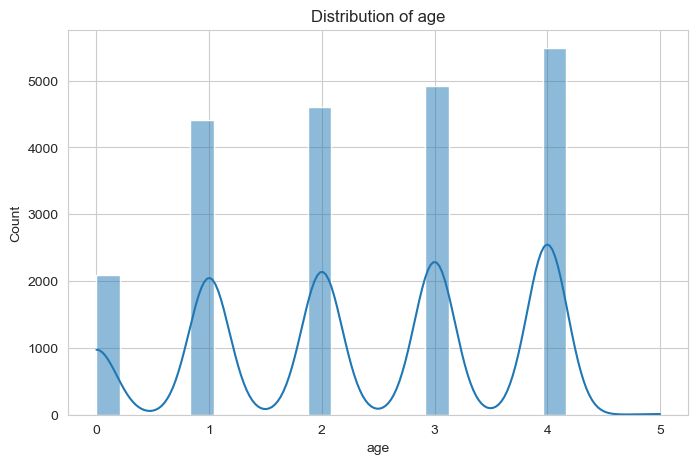

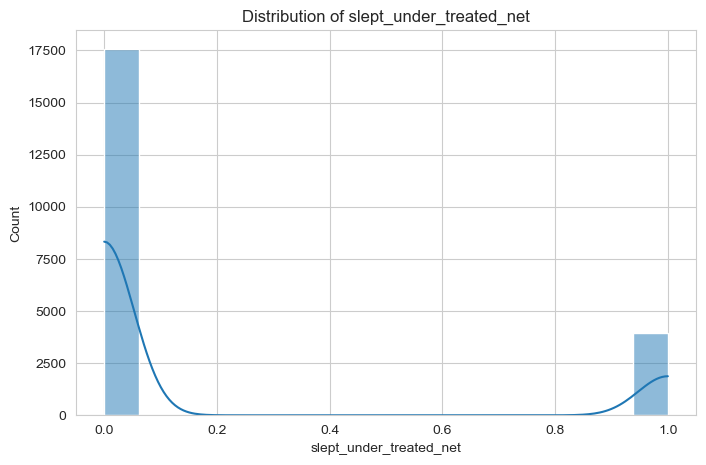

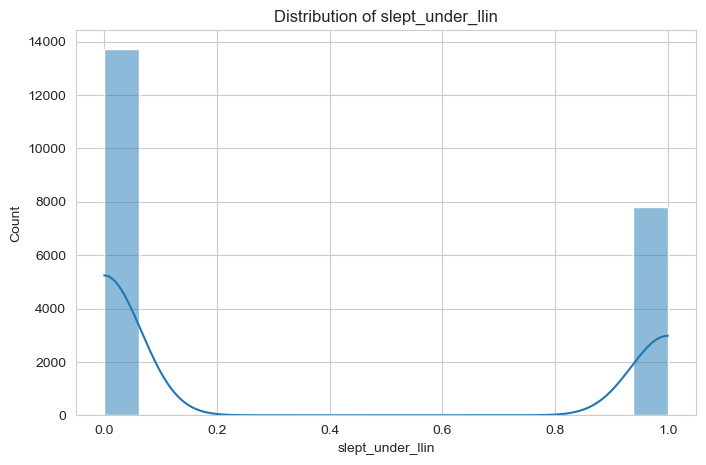

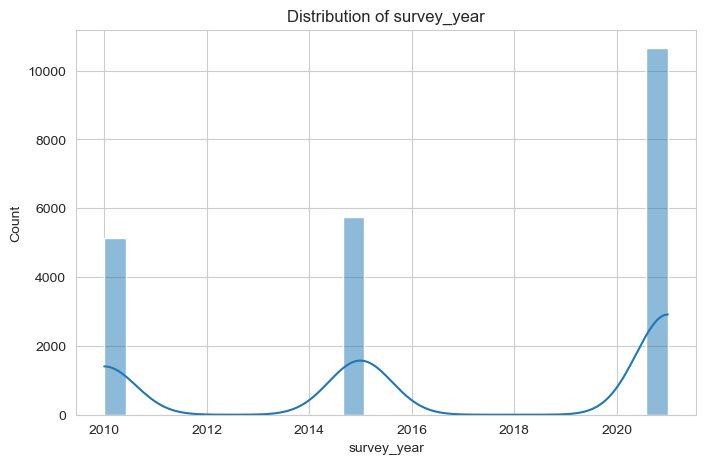

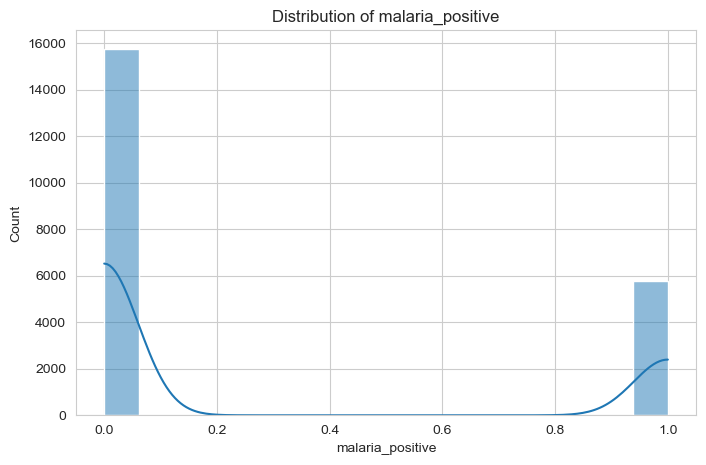

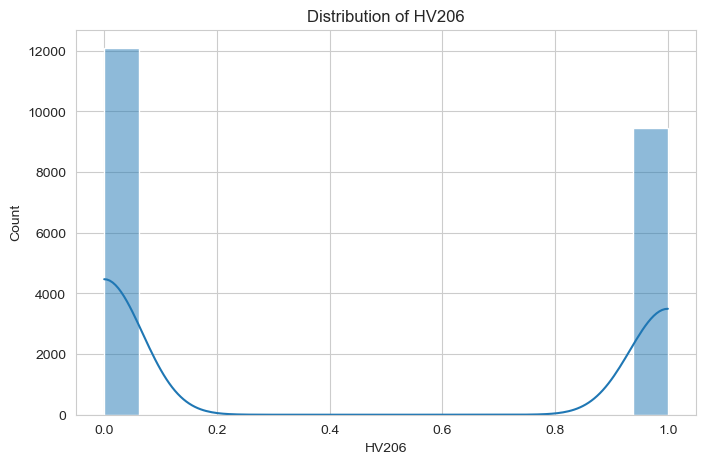

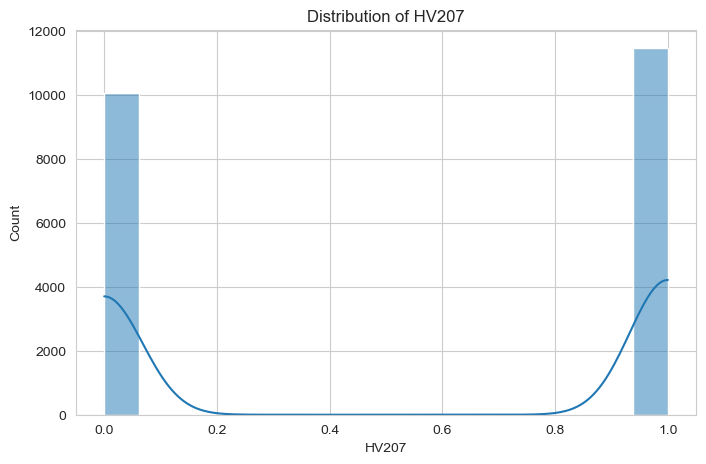

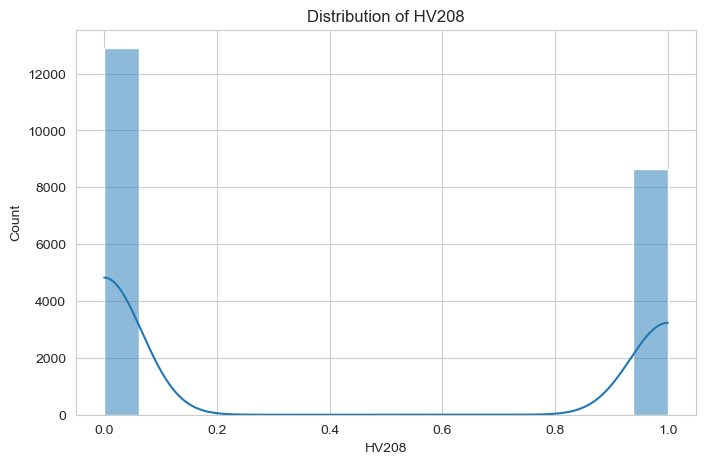

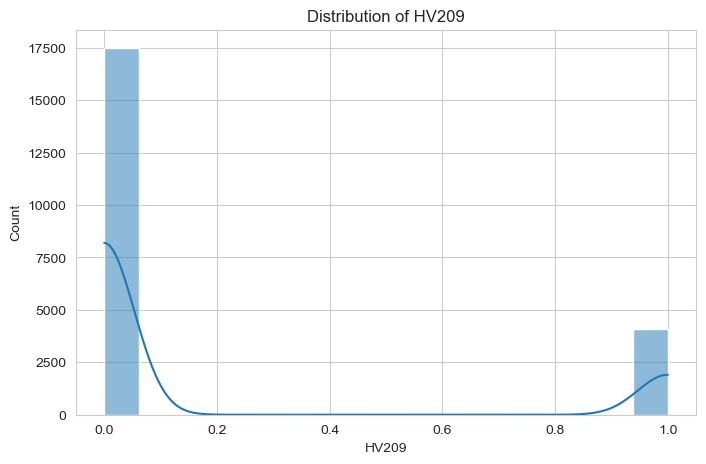

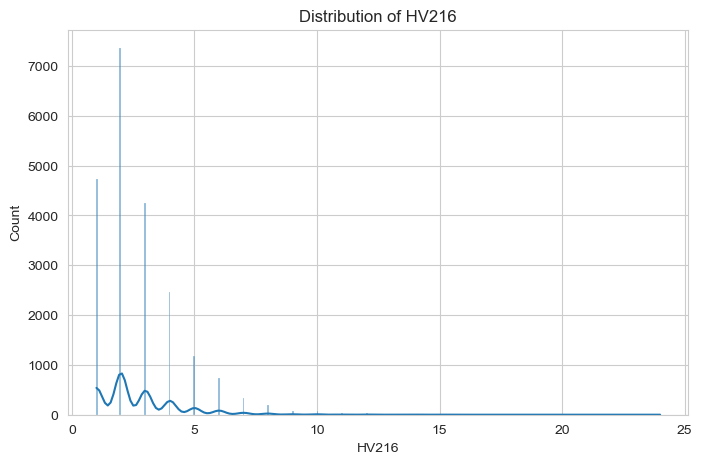

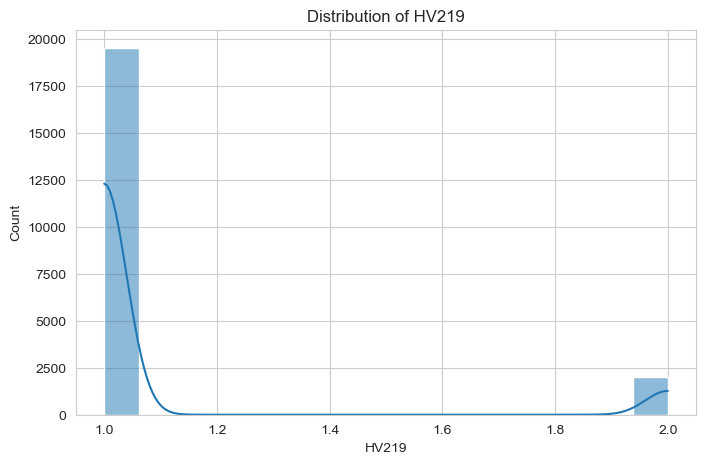

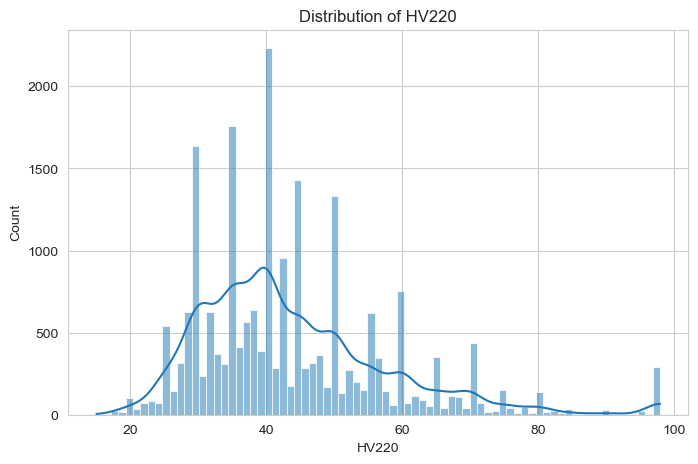

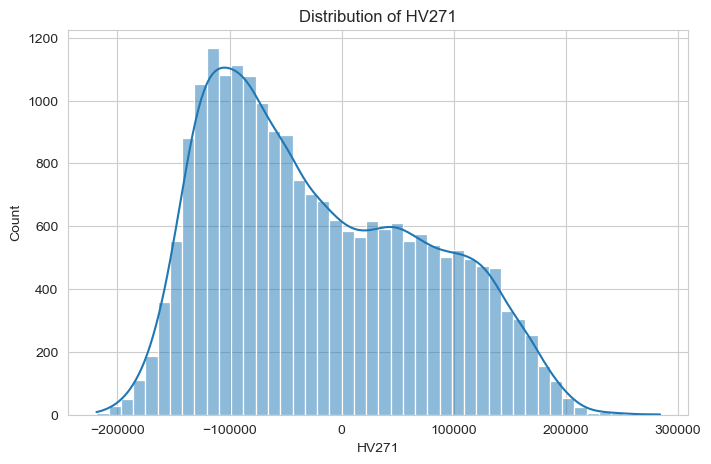

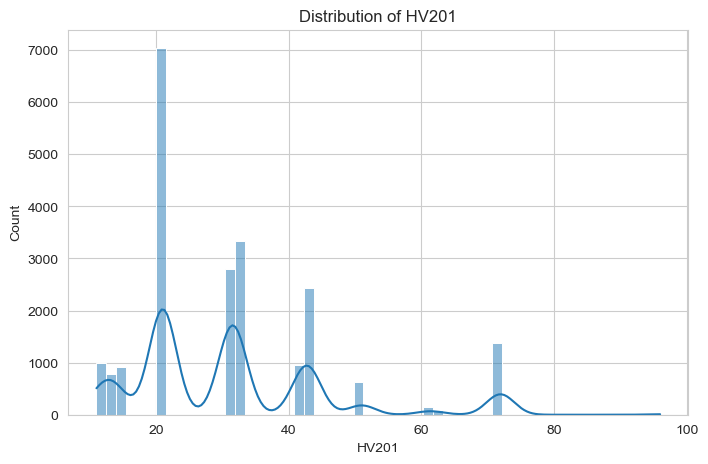

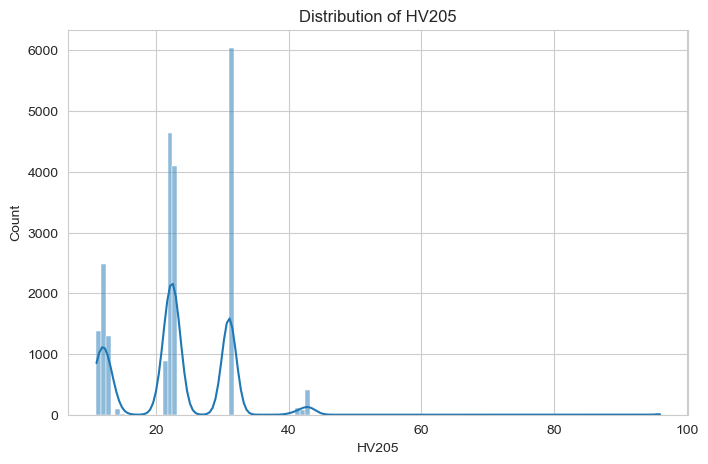

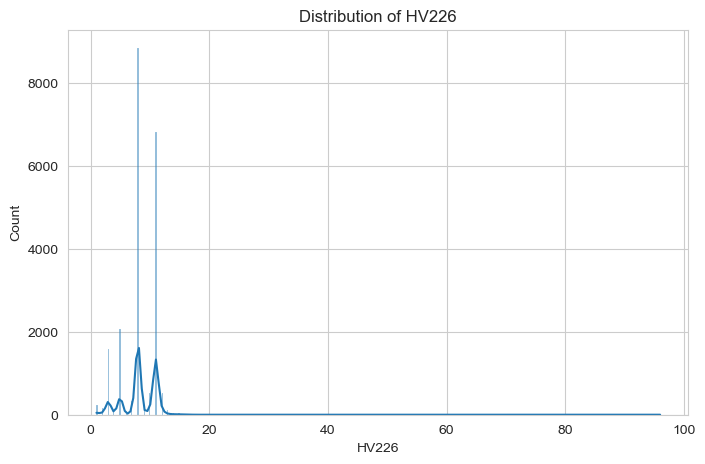

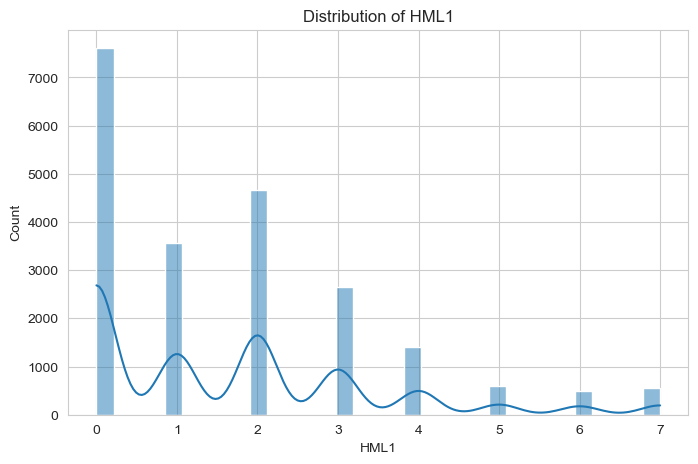

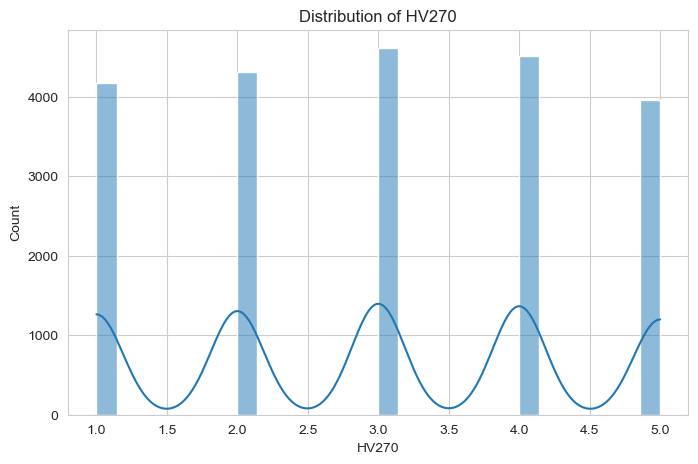

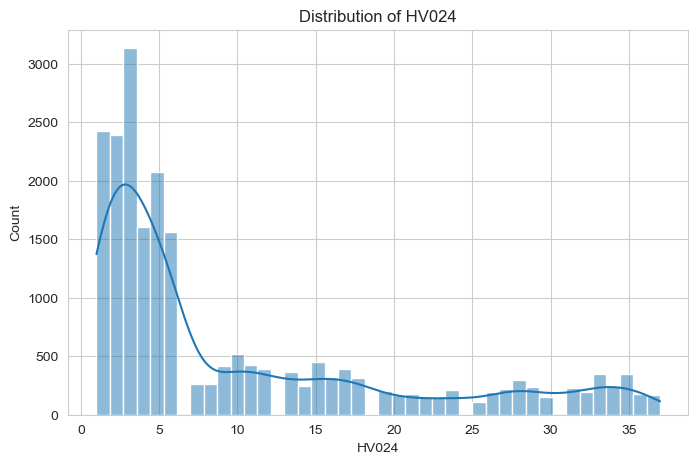

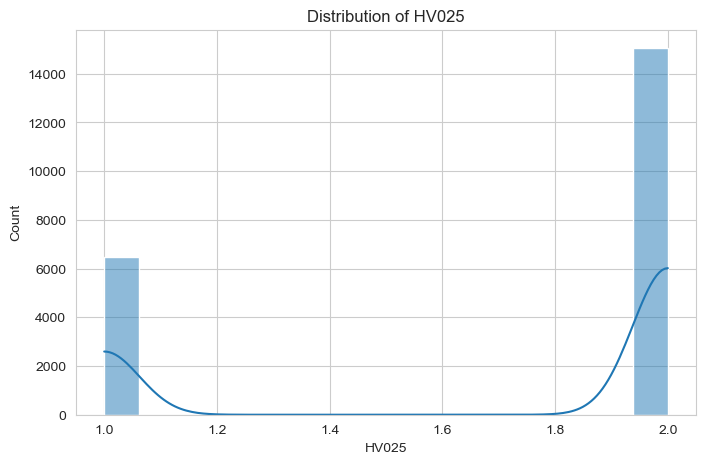

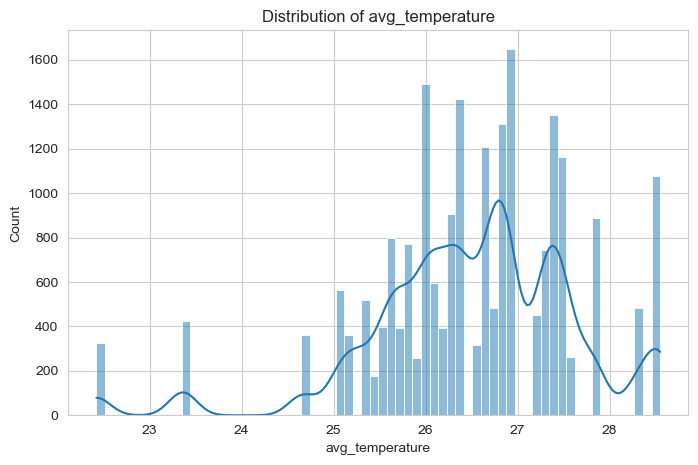

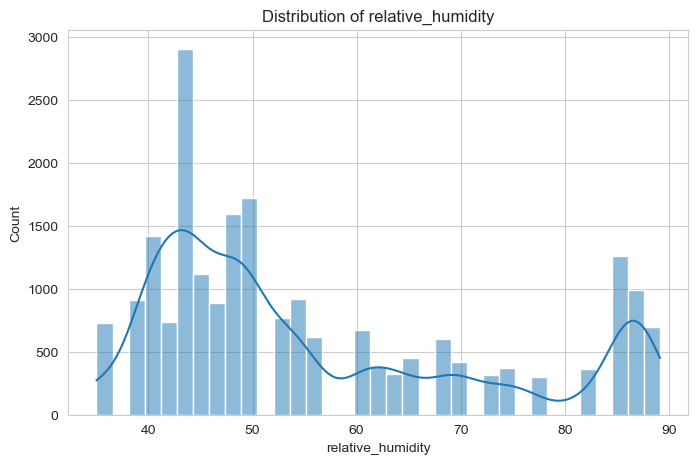

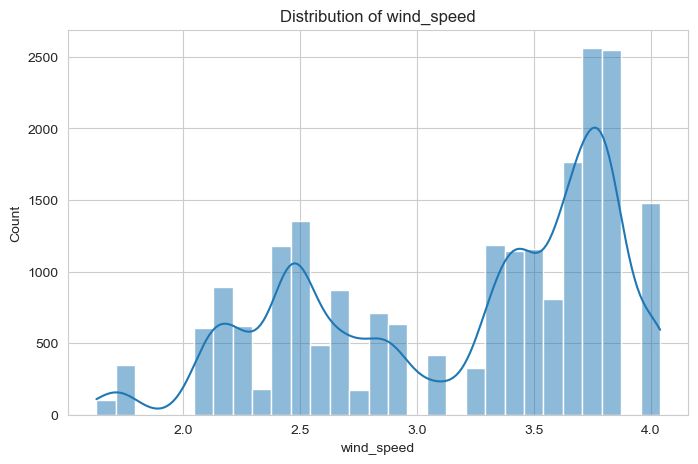

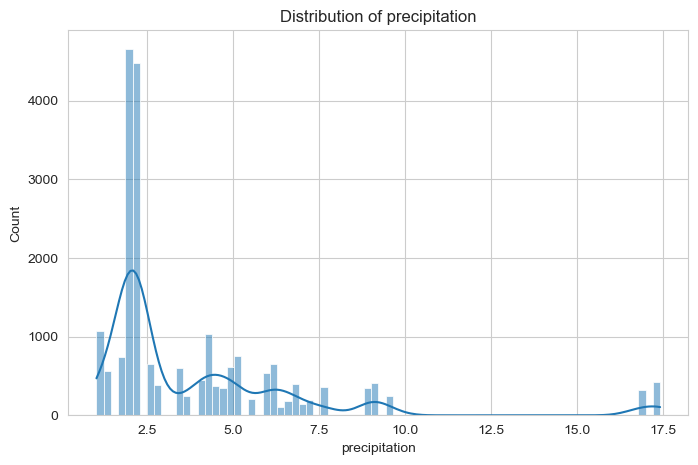

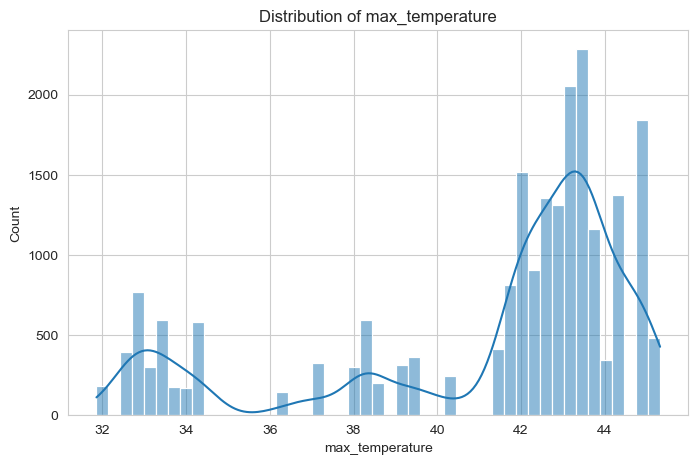

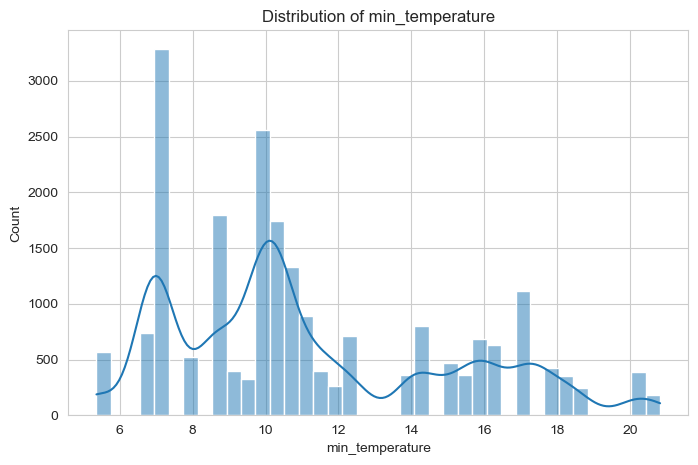

In [50]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

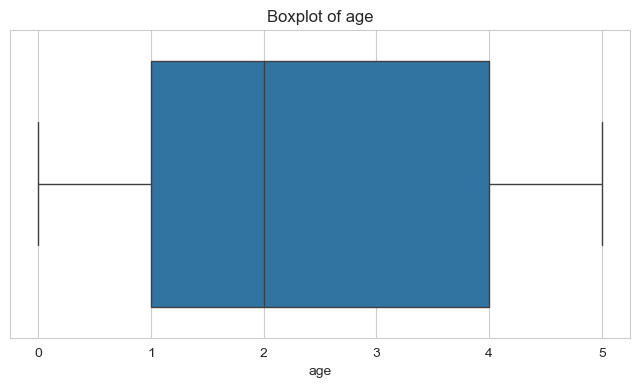

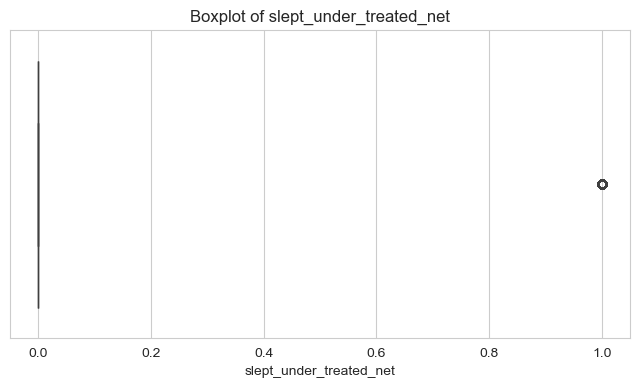

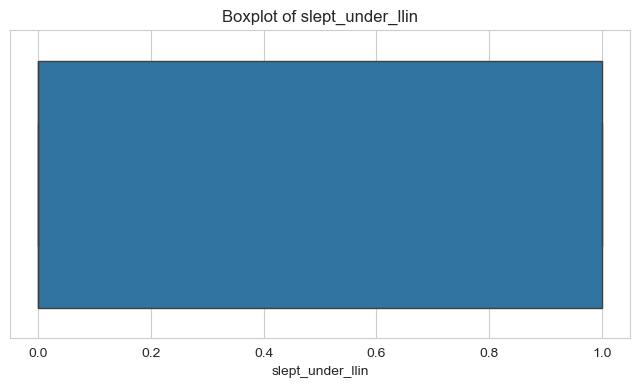

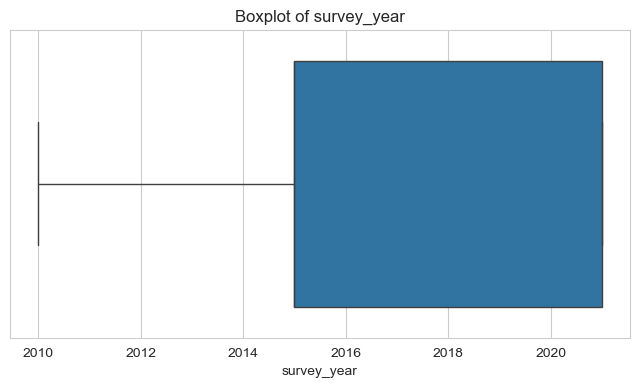

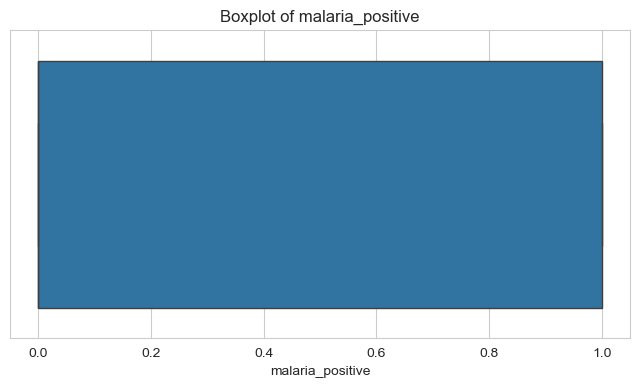

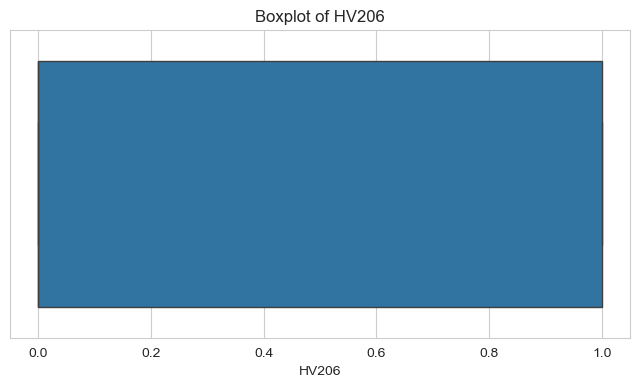

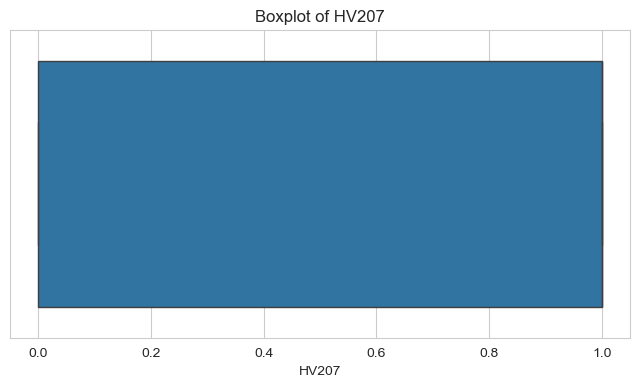

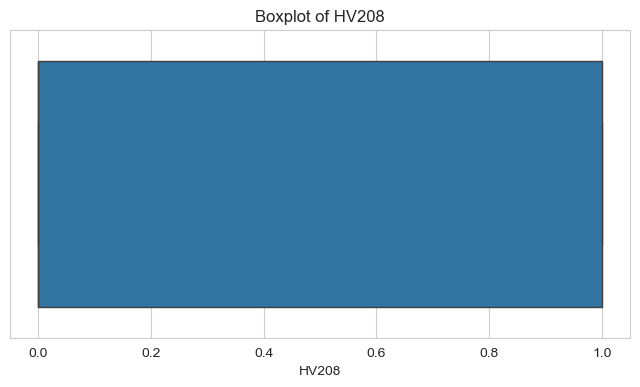

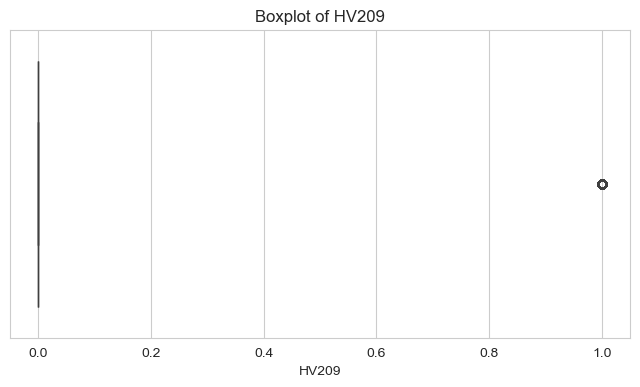

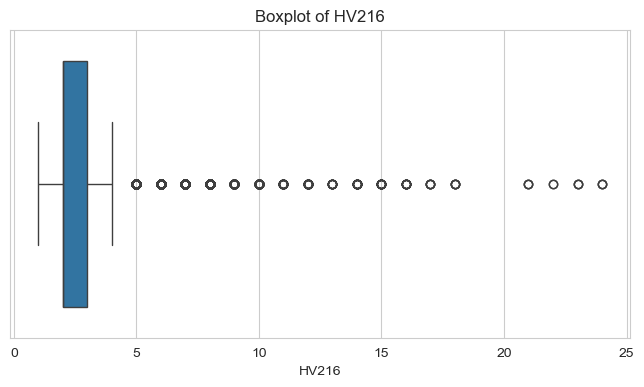

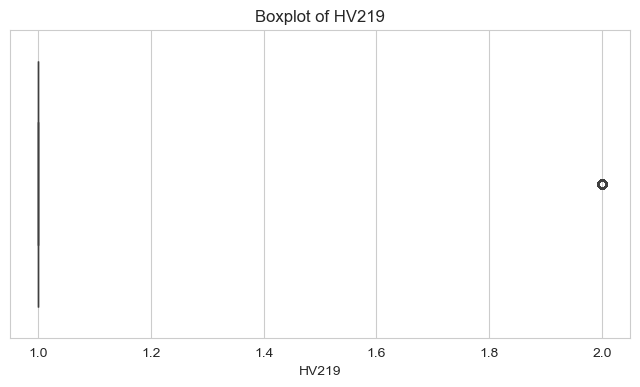

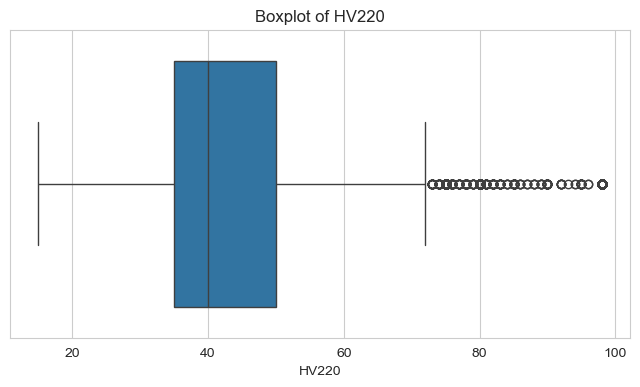

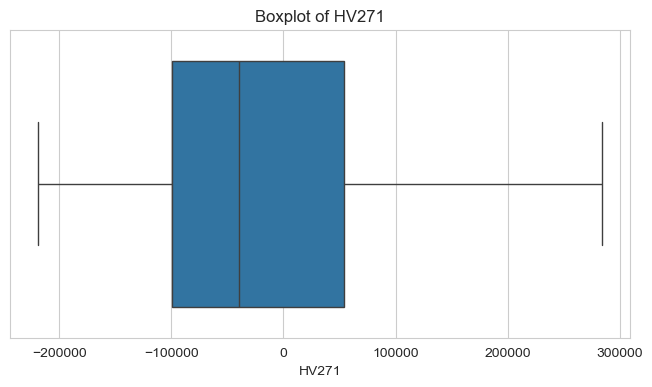

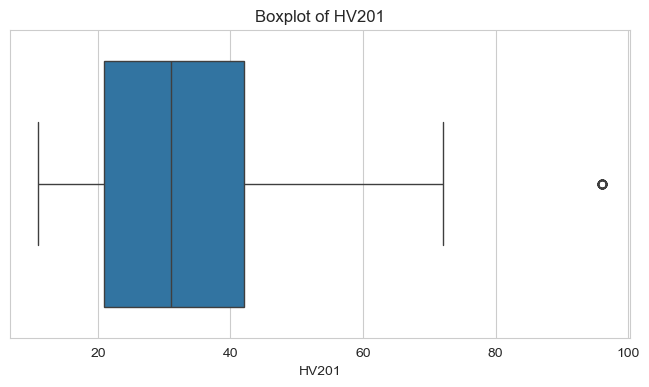

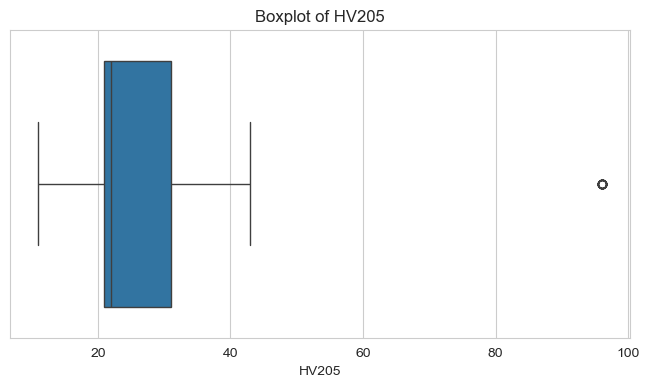

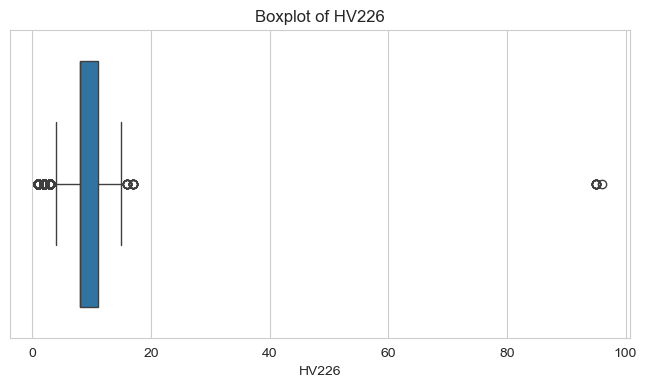

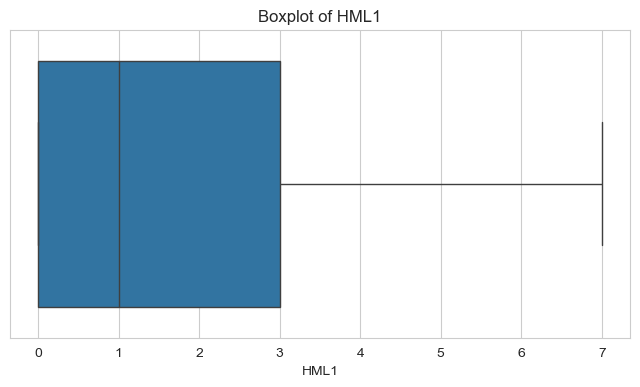

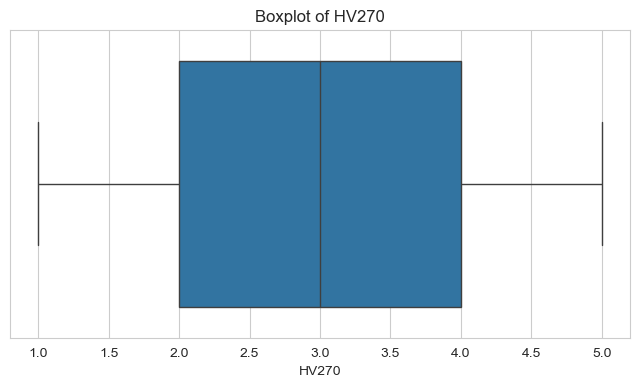

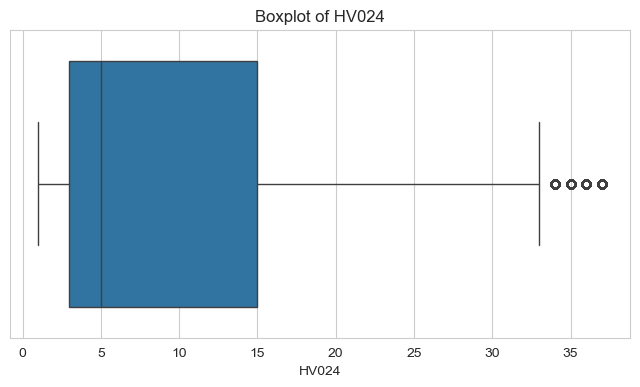

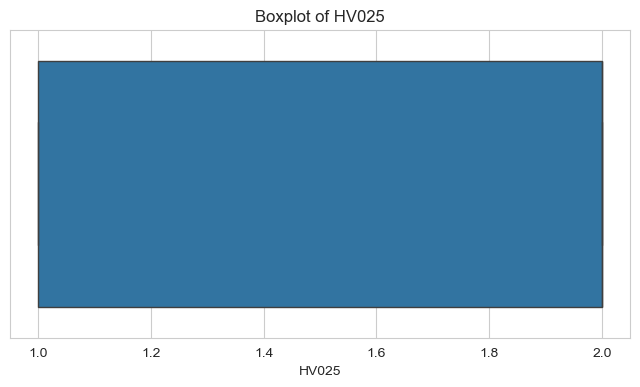

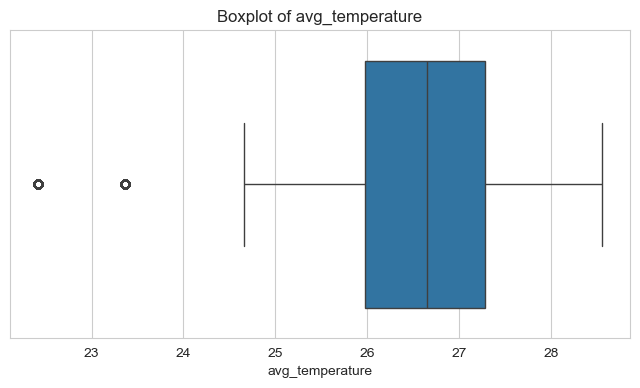

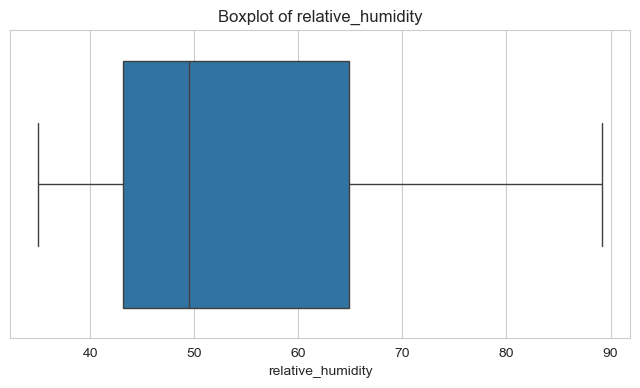

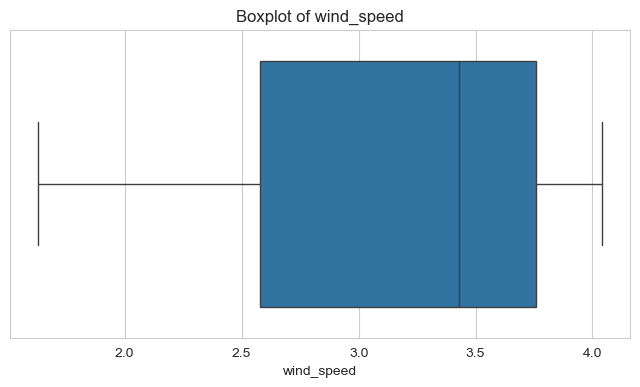

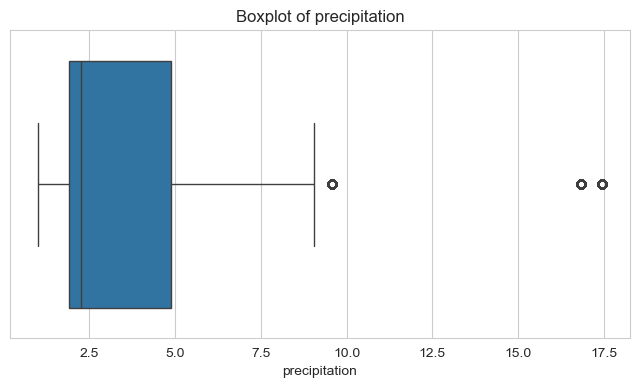

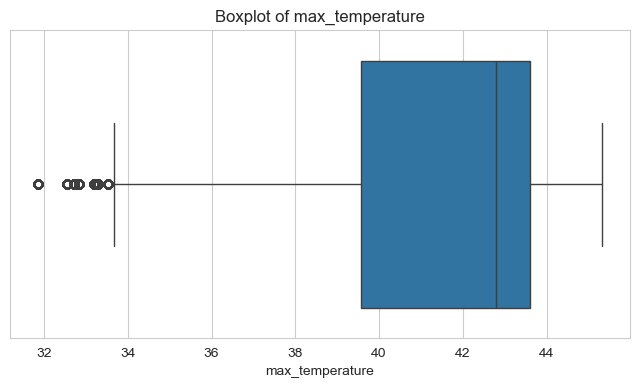

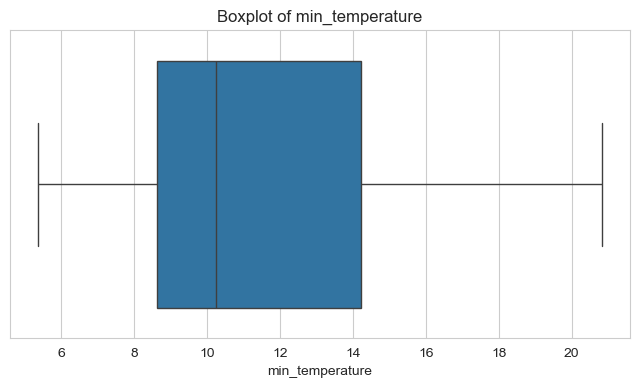

In [51]:
# Boxplot to check for outliers in numerical variables
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [16]:
# Frequency distribution for categorical variables
for col in cat_cols:
    print(df[col].value_counts())
    print('-'*50)

HHID
   63  81    9
233  1       9
  208  62    8
104 22       8
   19  21    8
            ..
  280  32    1
  280  24    1
  280  21    1
  280  10    1
  2 23       1
Name: count, Length: 13132, dtype: int64
--------------------------------------------------
state
Katsina        3134
Sokoto         2421
Zamfara        2390
Yobe           2071
Jigawa         1605
Borno          1563
Kano            521
Nasarawa        452
Kaduna          424
Bauchi          416
Kebbi           395
Taraba          388
Niger           363
Rivers          349
Delta           347
Plateau         325
Benue           317
Ebonyi          301
Adamawa         261
Gombe           259
Bayelsa         245
Fct             243
Cross River     237
Abia            231
Enugu           223
Ondo            211
Kogi            204
Imo             196
Anambra         194
Lagos           180
Oyo             179
Ogun            172
Kwara           170
Akwa Ibom       155
Ekiti           150
Osun            148
Edo         

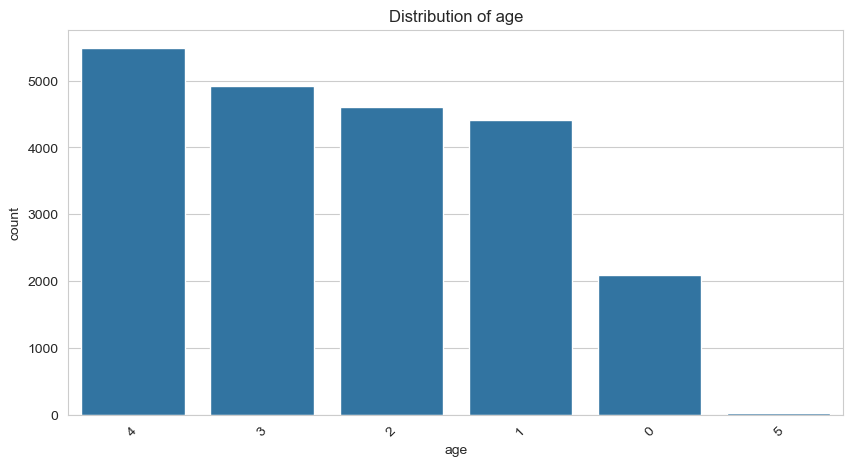

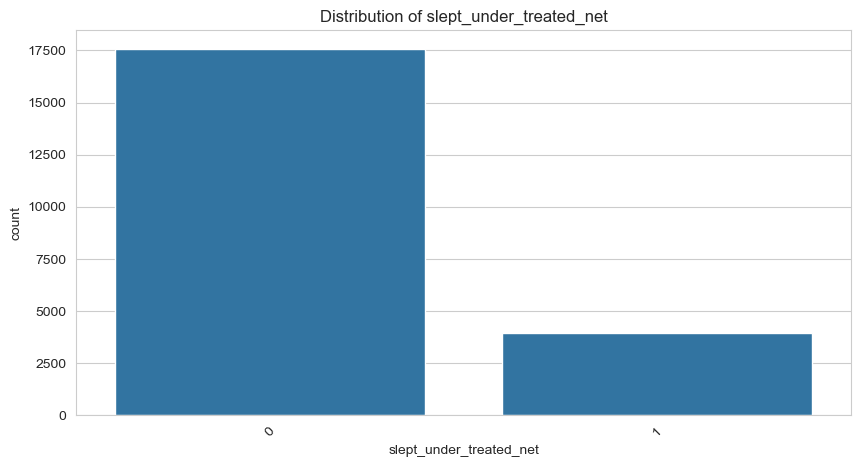

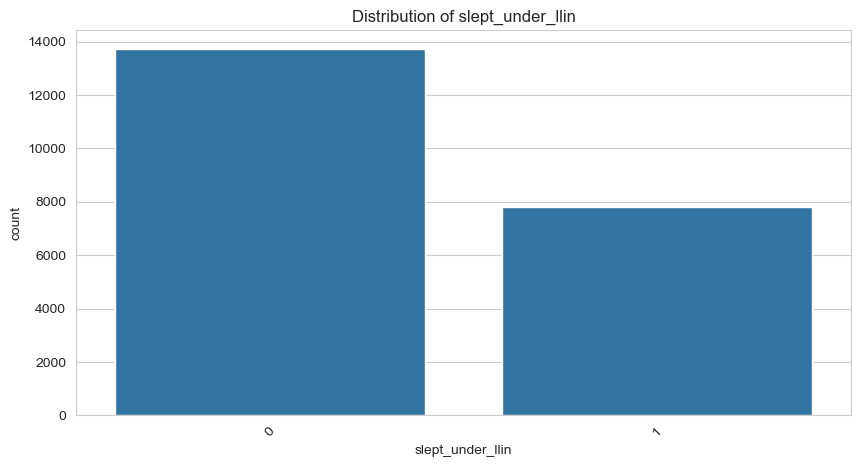

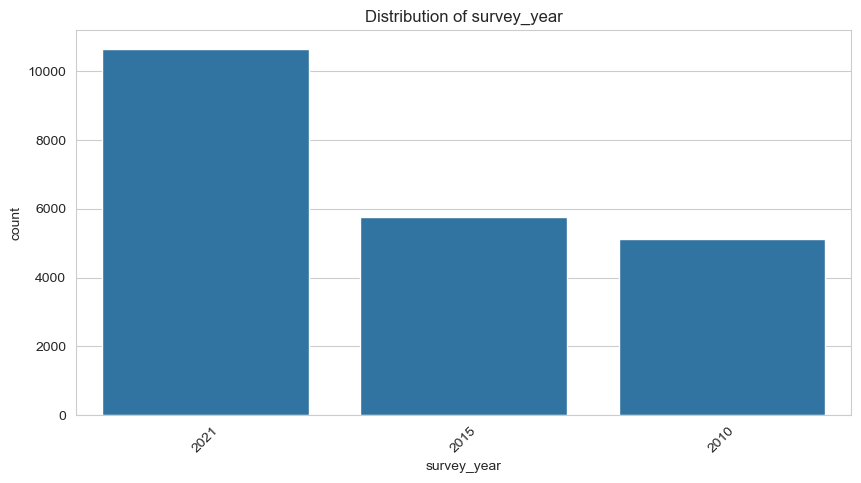

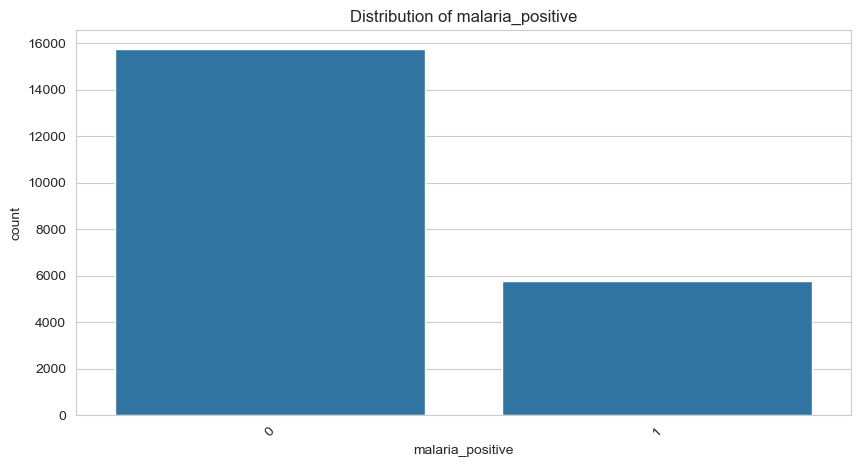

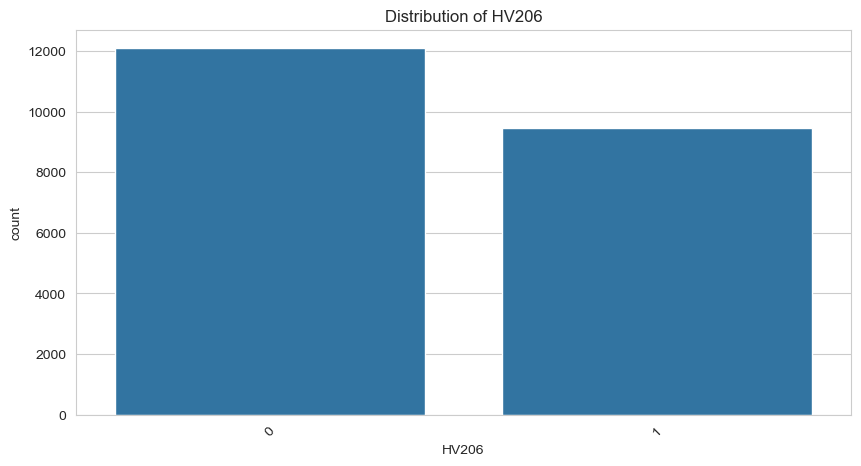

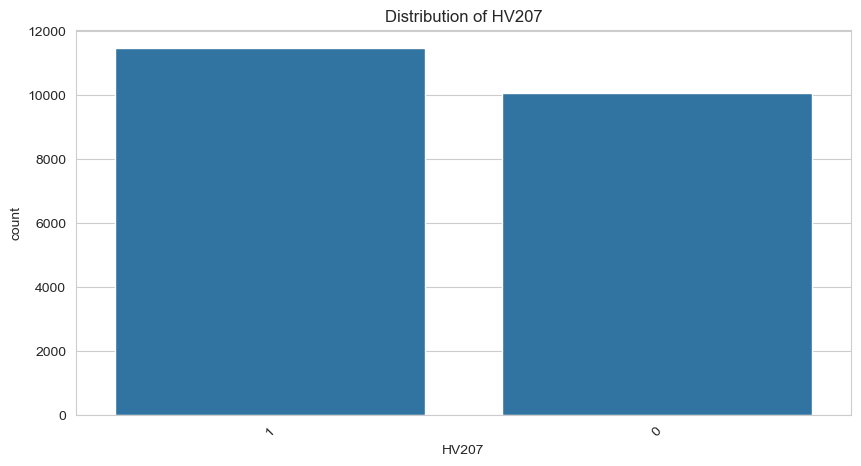

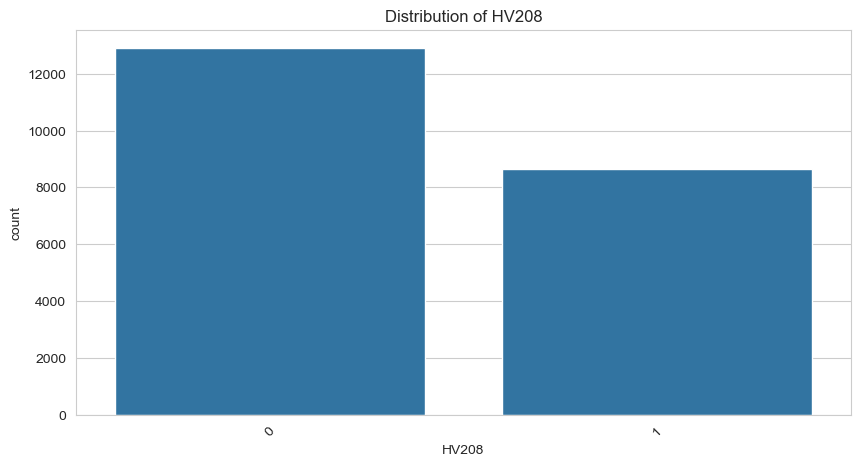

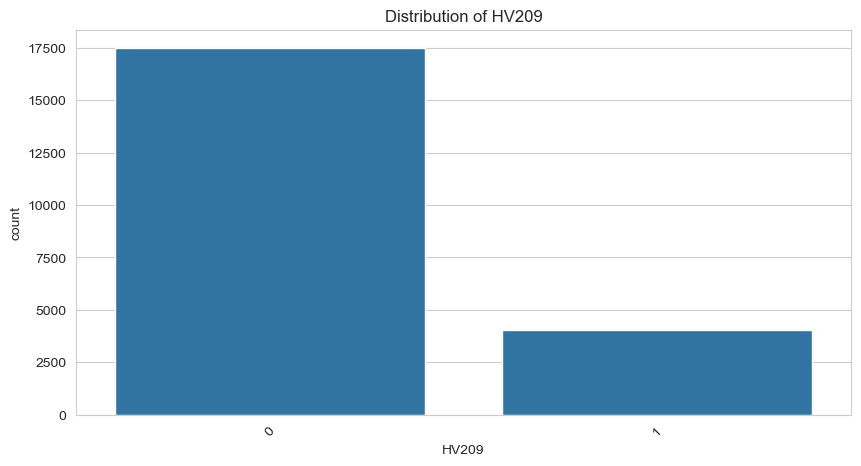

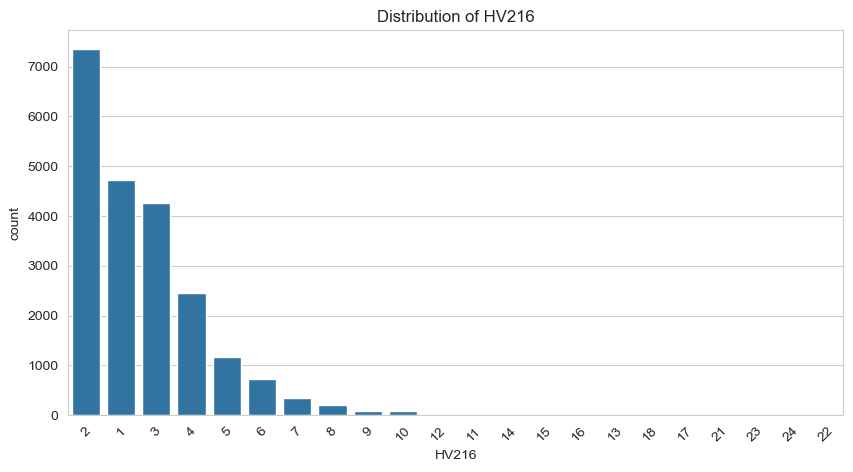

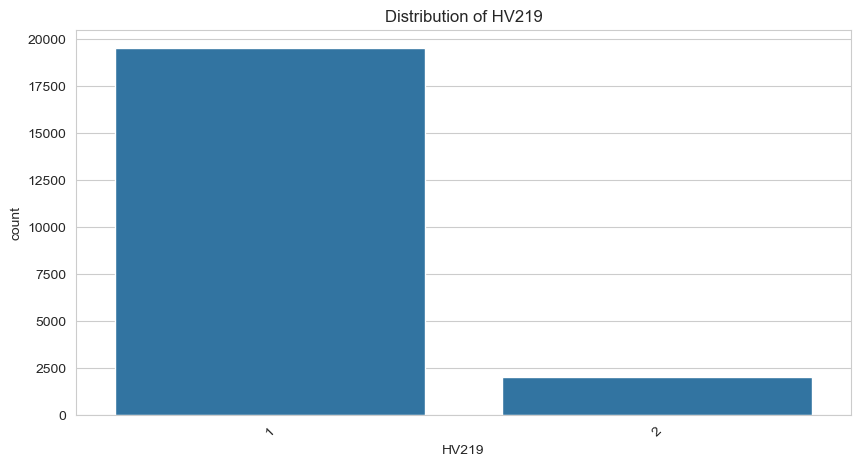

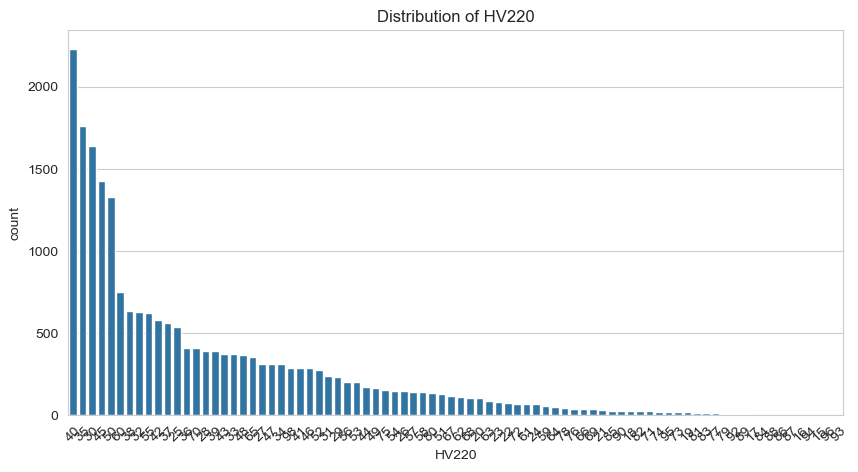

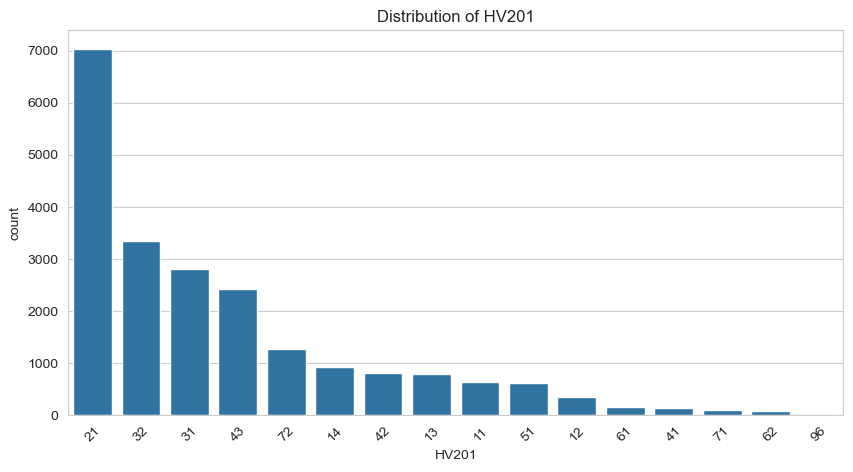

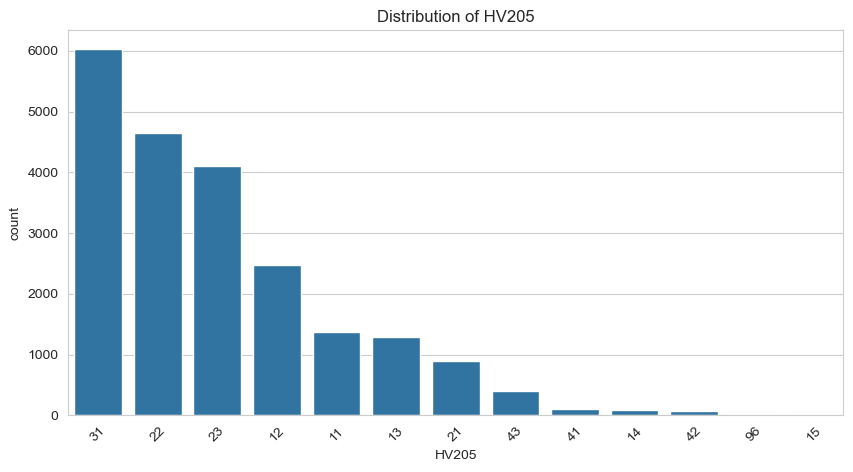

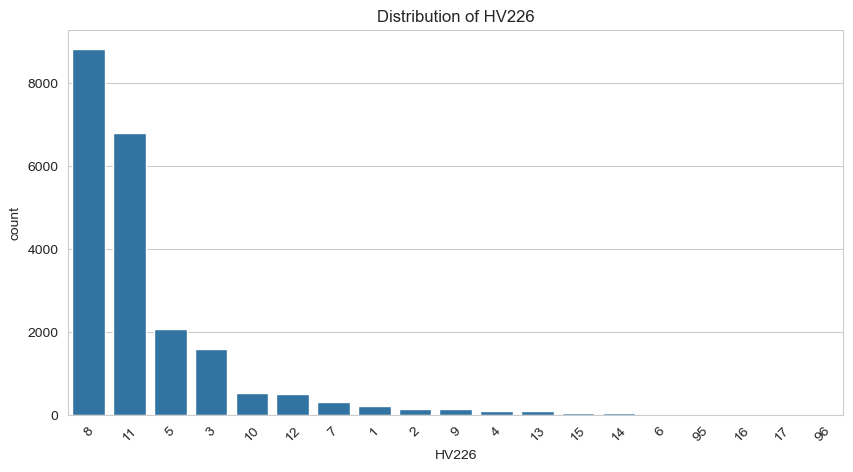

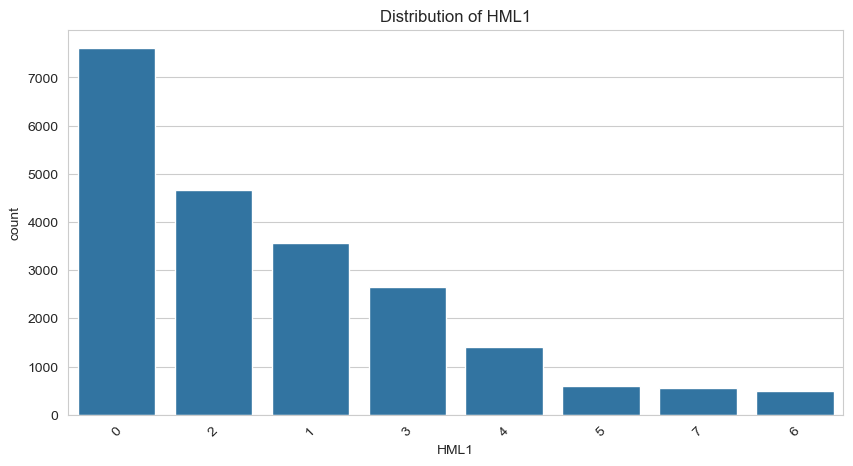

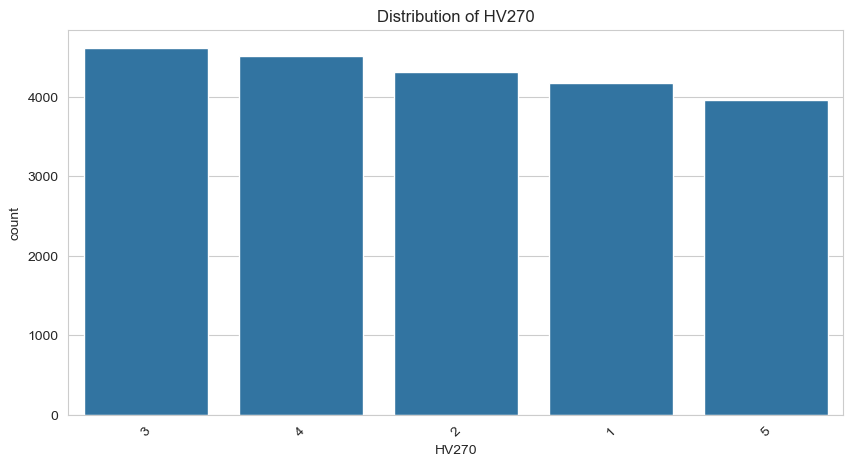

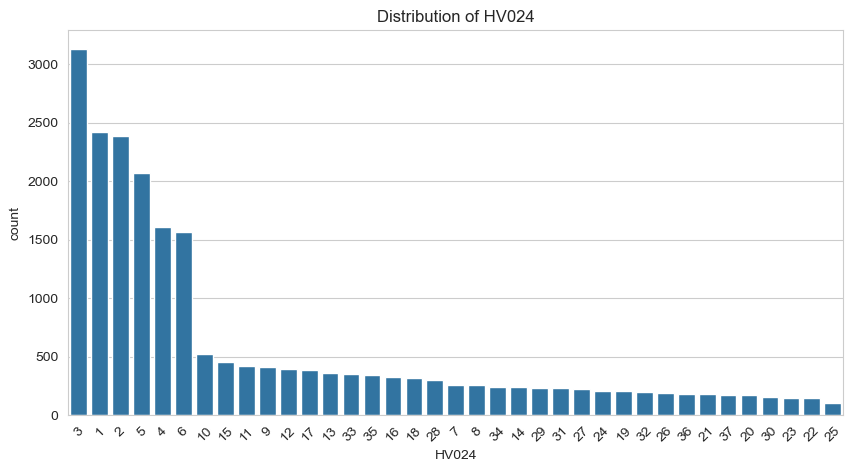

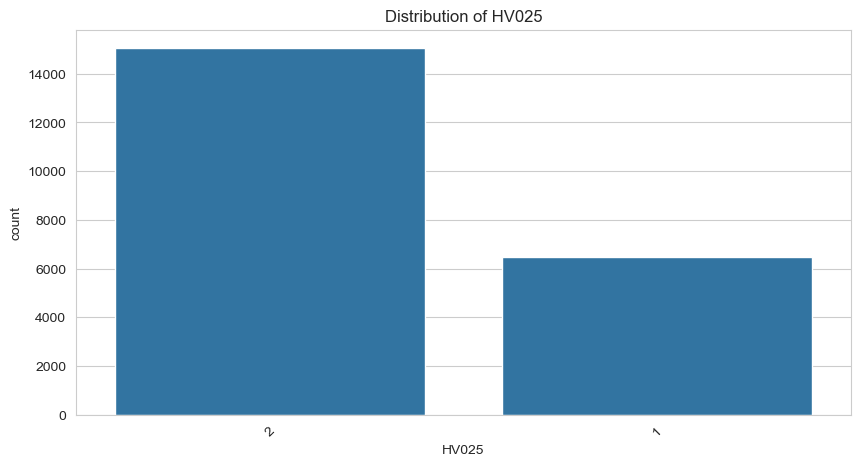

In [19]:
# Visualise categories
cat_cols = [
    'age',
    'slept_under_treated_net',
    'slept_under_llin',
    'survey_year',
    'malaria_positive',
    'HV206',
    'HV207',
    'HV208',
    'HV209',
    'HV216',
    'HV219',
    'HV220',
    'HV201',
    'HV205',
    'HV226',
    'HML1',
    'HV270',
    'HV024',
    'HV025'
]

# Distribution of categorical variables

for col in cat_cols:
    plt.figure(figsize=(10,5))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order
    )

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

    plt.show()

In [20]:
target = 'malaria_positive'
df[target].value_counts()

malaria_positive
0    15757
1     5788
Name: count, dtype: int64

In [21]:
df[target].value_counts(normalize=True)*100

malaria_positive
0    73.135298
1    26.864702
Name: proportion, dtype: float64

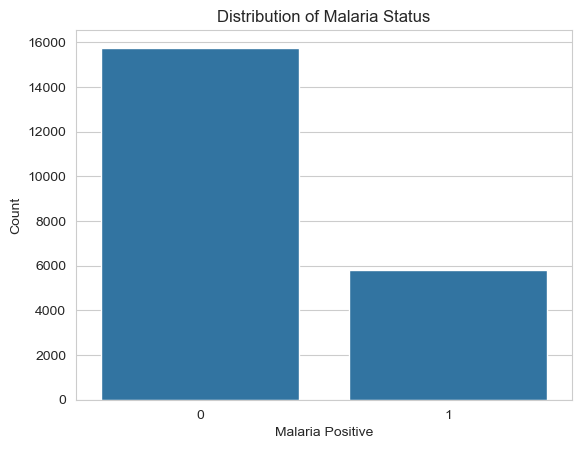

In [22]:
sns.countplot(
    data=df,
    x=target
)

plt.title('Distribution of Malaria Status')
plt.xlabel('Malaria Positive')
plt.ylabel('Count')
plt.show()

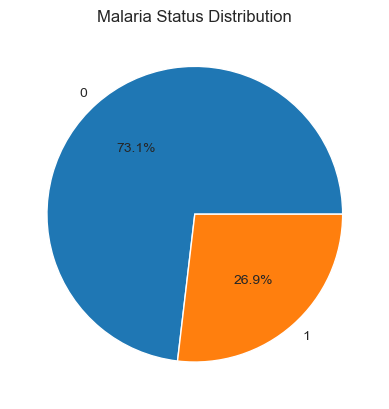

In [23]:
df[target].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Malaria Status Distribution')
plt.show()

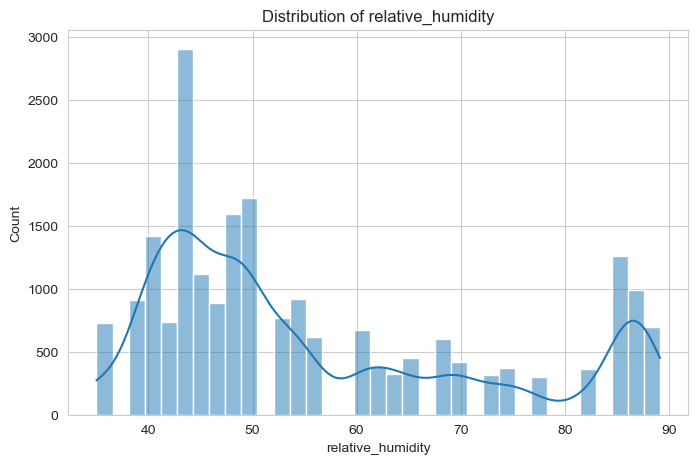

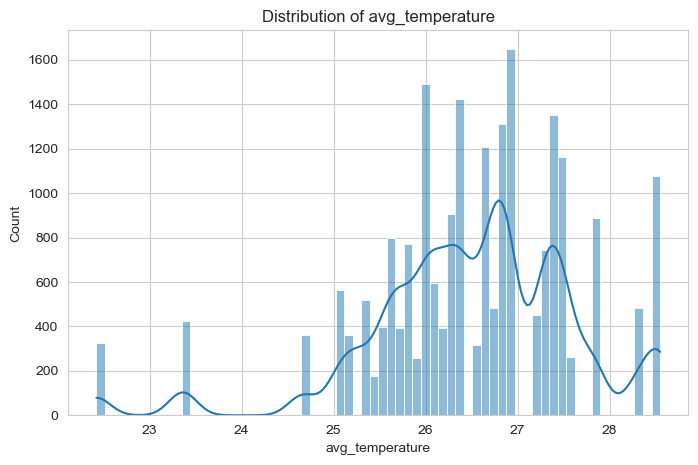

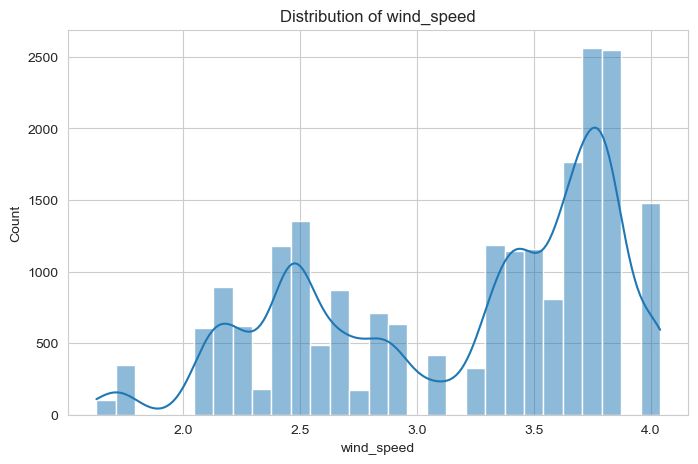

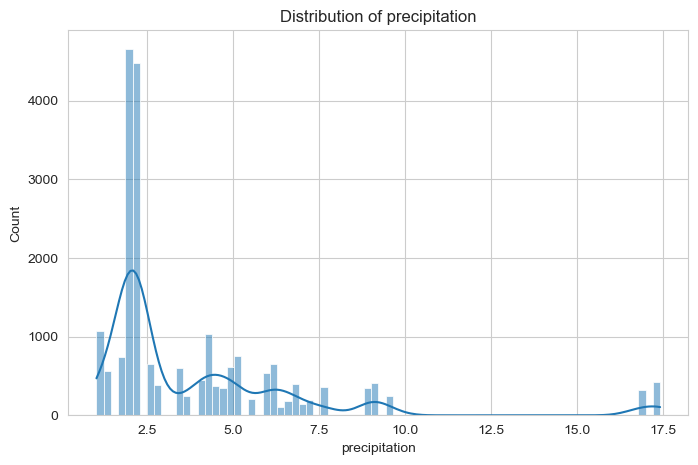

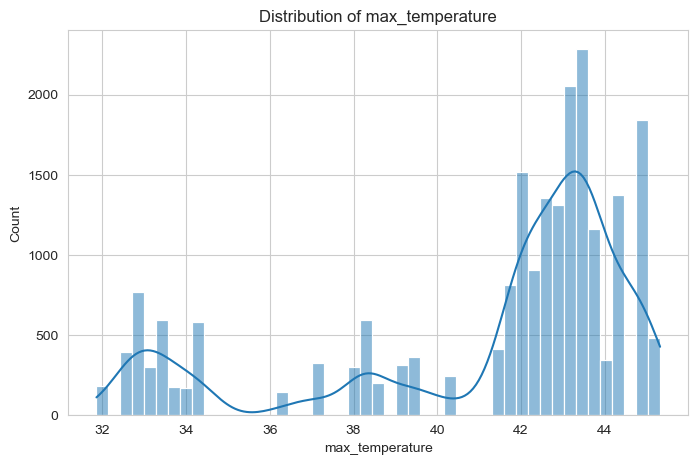

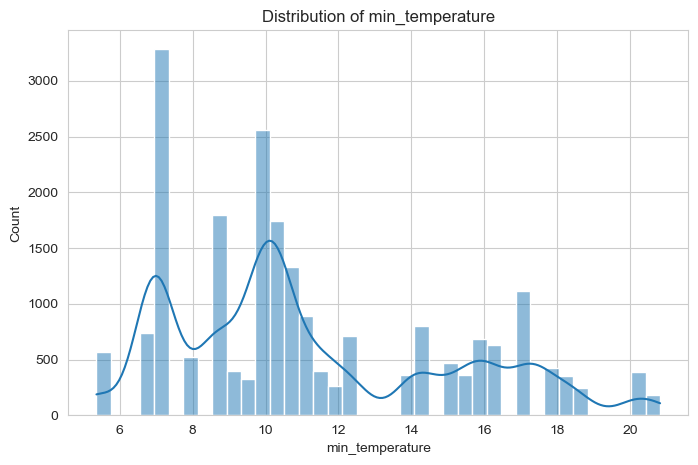

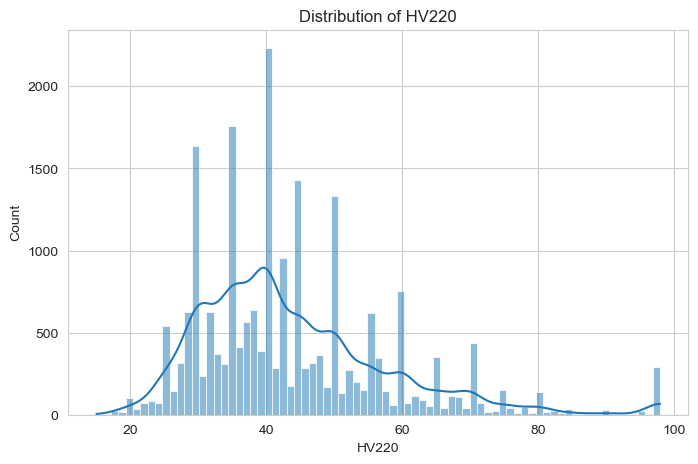

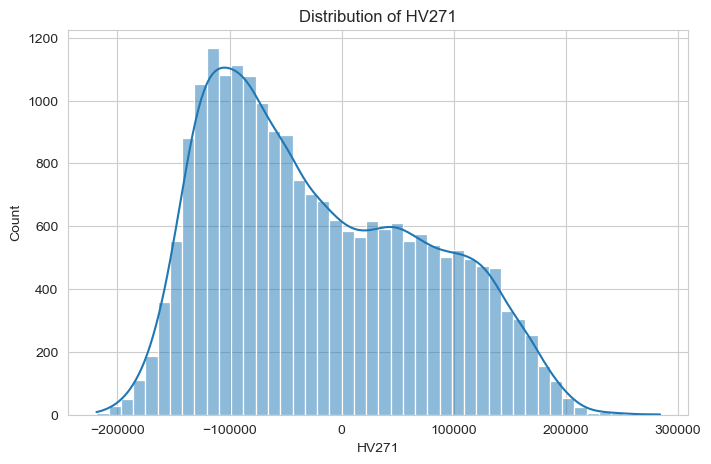

In [24]:
# Distribution of the numerical variables
## To identify rare categories and to identify imbalance

num_cols = [
    'relative_humidity',
    'avg_temperature',
    'wind_speed',
    'precipitation',
    'max_temperature',
    'min_temperature',
    'HV220',
    'HV271'
]

for col in num_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
# Correlation analysis
## To detect multicollinearity and to identify redundant variables

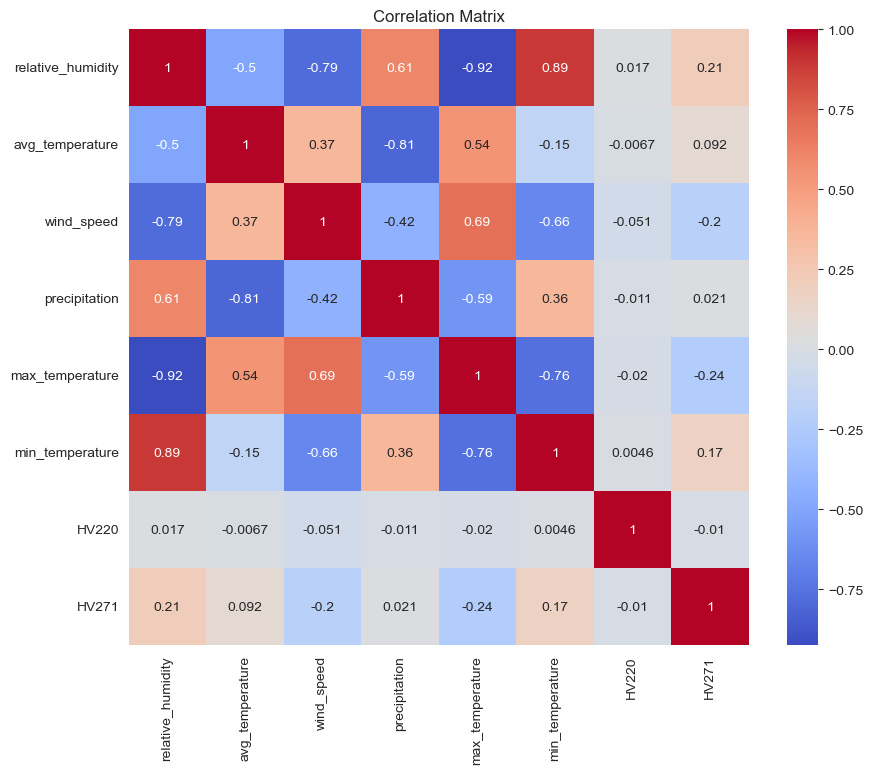

In [26]:
# Correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [53]:
df[['max_temperature', 'min_temperature']].describe()

,max_temperature,min_temperature
count,21545.000000,21545.000000
mean,41.248265,11.174587
std,3.774415,3.814709
min,31.860000,5.360000
25%,39.580000,8.610000
50%,42.790000,10.250000
75%,43.600000,14.210000
max,45.320000,20.830000


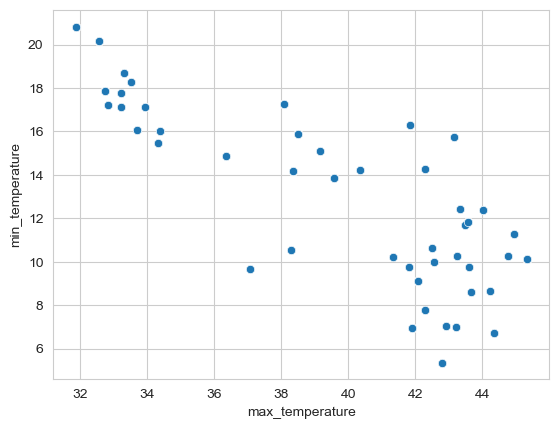

In [54]:
sns.scatterplot(
    data=df,
    x='max_temperature',
    y='min_temperature'
)
plt.show()

# Checking Relationship Between Predictors and Target

In [ ]:
# Numerical predictors versus malaria status 
## To See if predictor distributions differ between malaria groups.

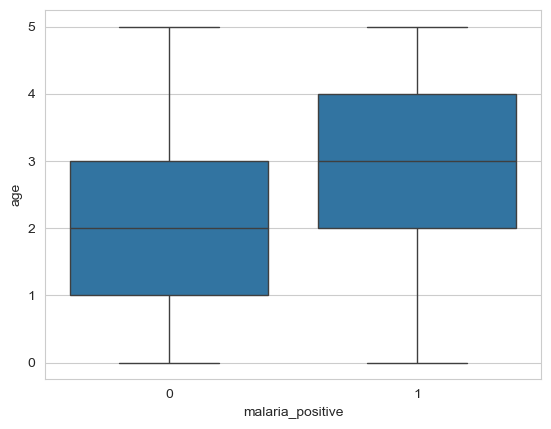

In [29]:
# Age vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='age'
)

plt.show()

In [55]:
# Checking the statistical significance
from scipy.stats import mannwhitneyu

mal_pos = df[df['malaria_positive']==1]['age']
mal_neg = df[df['malaria_positive']==0]['age']

stat, p = mannwhitneyu(mal_pos, mal_neg)

print('P-value:', p)

P-value: 7.447418537994346e-71


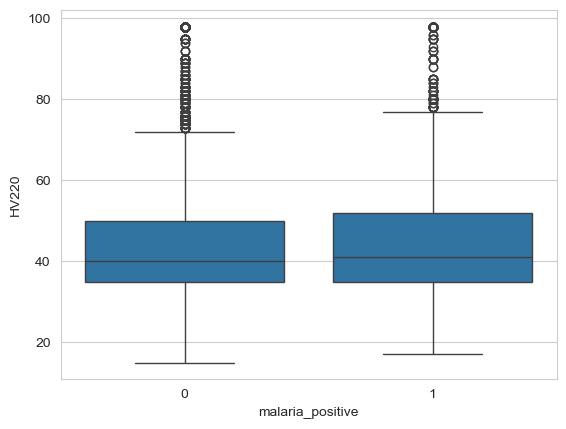

In [52]:
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='HV220'
)

plt.show()

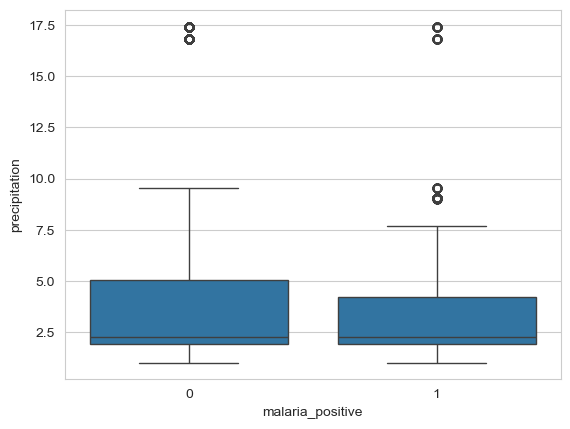

In [32]:
# Rainfall vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='precipitation'
)

plt.show()

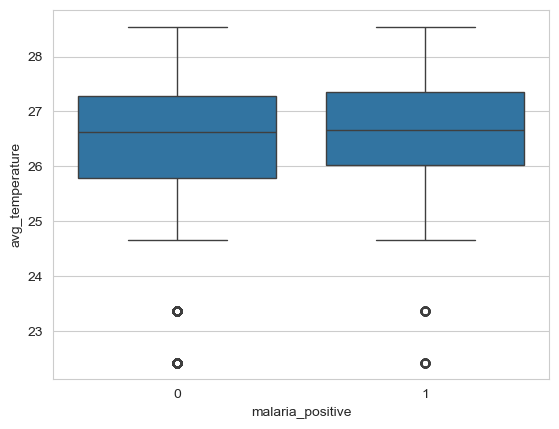

In [4]:
# Temperature vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='avg_temperature'
)

plt.show()

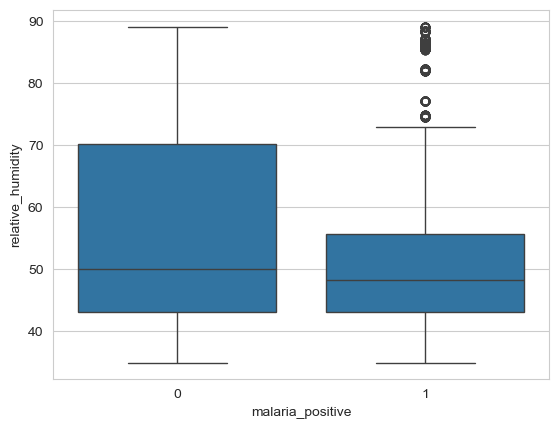

In [5]:
# Relative humidity vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='relative_humidity'
)
plt.show()

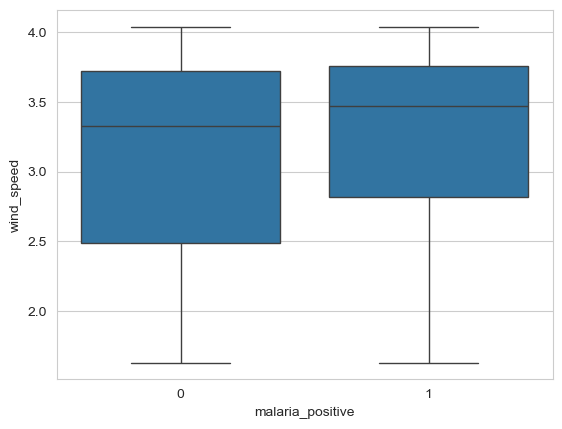

In [6]:
# wind_speed vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='wind_speed'
)
plt.show()

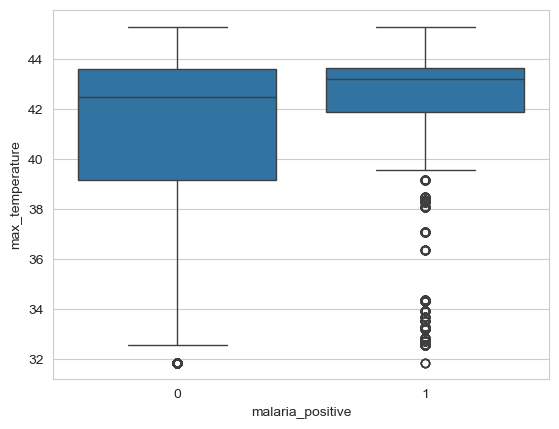

In [7]:
# max_temperature vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='max_temperature'
)
plt.show()

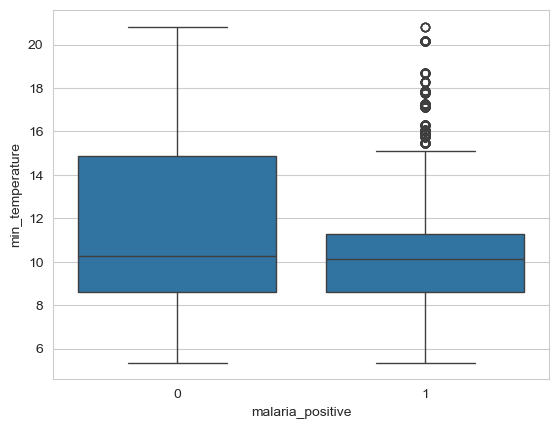

In [8]:
# min_temperature vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='min_temperature'
)
plt.show()

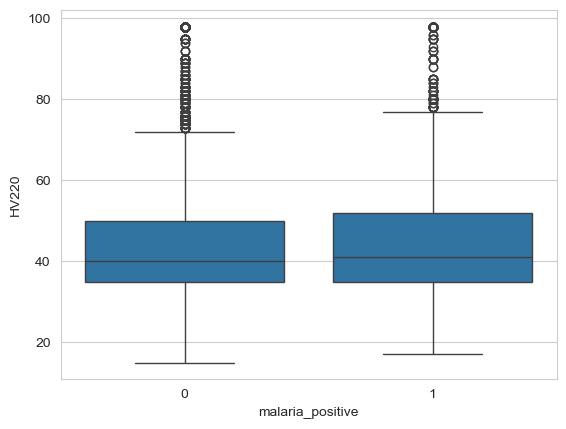

In [9]:
# Age of household head vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='HV220'
)
plt.show()

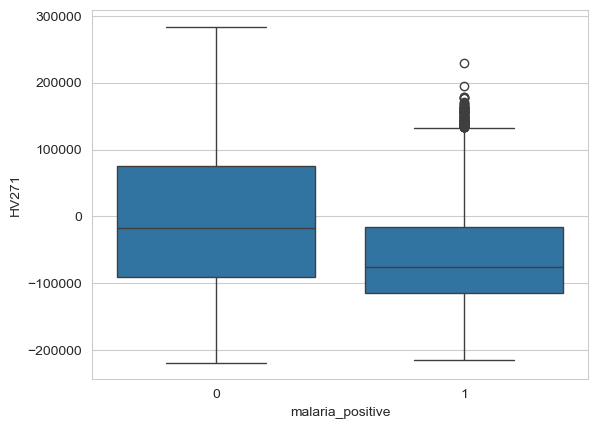

In [10]:
# Household wealth index score vs Malaria Status
sns.boxplot(
    data=df,
    x='malaria_positive',
    y='HV271'
)
plt.show()

In [ ]:
# Statistical tests
## To determine if predictors are associated with malaria positivity.

In [20]:
# For numerical or Continuous variables:

from scipy.stats import mannwhitneyu

for col in [
    'age',
    'relative_humidity',
    'avg_temperature',
    'wind_speed',
    'precipitation',
    'max_temperature',
    'min_temperature'
]:

    pos = df[df['malaria_positive']==1][col]
    neg = df[df['malaria_positive']==0][col]

    stat,p = mannwhitneyu(
        pos,
        neg
    )

    print(col)
    print('p-value:',p)
    print('----------------')

age
p-value: 7.447418537994346e-71
----------------
relative_humidity
p-value: 1.948064180144848e-47
----------------
avg_temperature
p-value: 6.612968941484188e-18
----------------
wind_speed
p-value: 5.693059252595783e-45
----------------
precipitation
p-value: 1.882039085728999e-28
----------------
max_temperature
p-value: 1.207117930175063e-90
----------------
min_temperature
p-value: 1.2231319817050165e-31
----------------


In [21]:
# Statistical test for Categorical variables:

from scipy.stats import chi2_contingency

cat_cols = [
    'slept_under_treated_net',
    'slept_under_llin',
    'HV206',
    'HV207',
    'HV208',
    'HV209',
    'state'
]

for col in cat_cols:

    table = pd.crosstab(
        df[col],
        df['malaria_positive']
    )

    chi2,p,dof,expected = chi2_contingency(table)

    print(col)
    print('p-value:',p)
    print('----------------')

slept_under_treated_net
p-value: 5.185579822157483e-17
----------------
slept_under_llin
p-value: 0.6629164863713783
----------------
HV206
p-value: 2.7916730158284775e-167
----------------
HV207
p-value: 2.2211204414192196e-07
----------------
HV208
p-value: 8.899983440251772e-184
----------------
HV209
p-value: 4.88381696251571e-151
----------------
state
p-value: 6.183036783133221e-190
----------------


In [22]:
eda_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

eda_summary

,Data Type,Missing Values,Unique Values
age,int64,0,6
slept_under_treated_net,int64,0,2
slept_under_llin,int64,0,2
survey_year,int64,0,3
malaria_positive,int64,0,2
HV206,int64,0,2
HV207,int64,0,2
HV208,int64,0,2
HV209,int64,0,2
HV216,int64,0,22


# Checking which variables have outliers

Since my project aims at:

Machine Learning Prediction of Malaria Infection Risk

I will likely use:

- Random Forest
- XGBoost
- CatBoost

These handle outliers quite well.

Therefore, I probably do not need to remove many outliers.

Outlier Assessment

Outliers were assessed using boxplots and the Interquartile Range (IQR) method. Several variables showed observations outside the IQR boundaries, particularly binary DHS indicators and climatic variables. However, these observations represented genuine values arising from categorical coding schemes and geographical variations across Nigerian states rather than data entry errors. Therefore, no observations were removed or winsorized (capped) to preserve potentially important epidemiological information for malaria prediction.

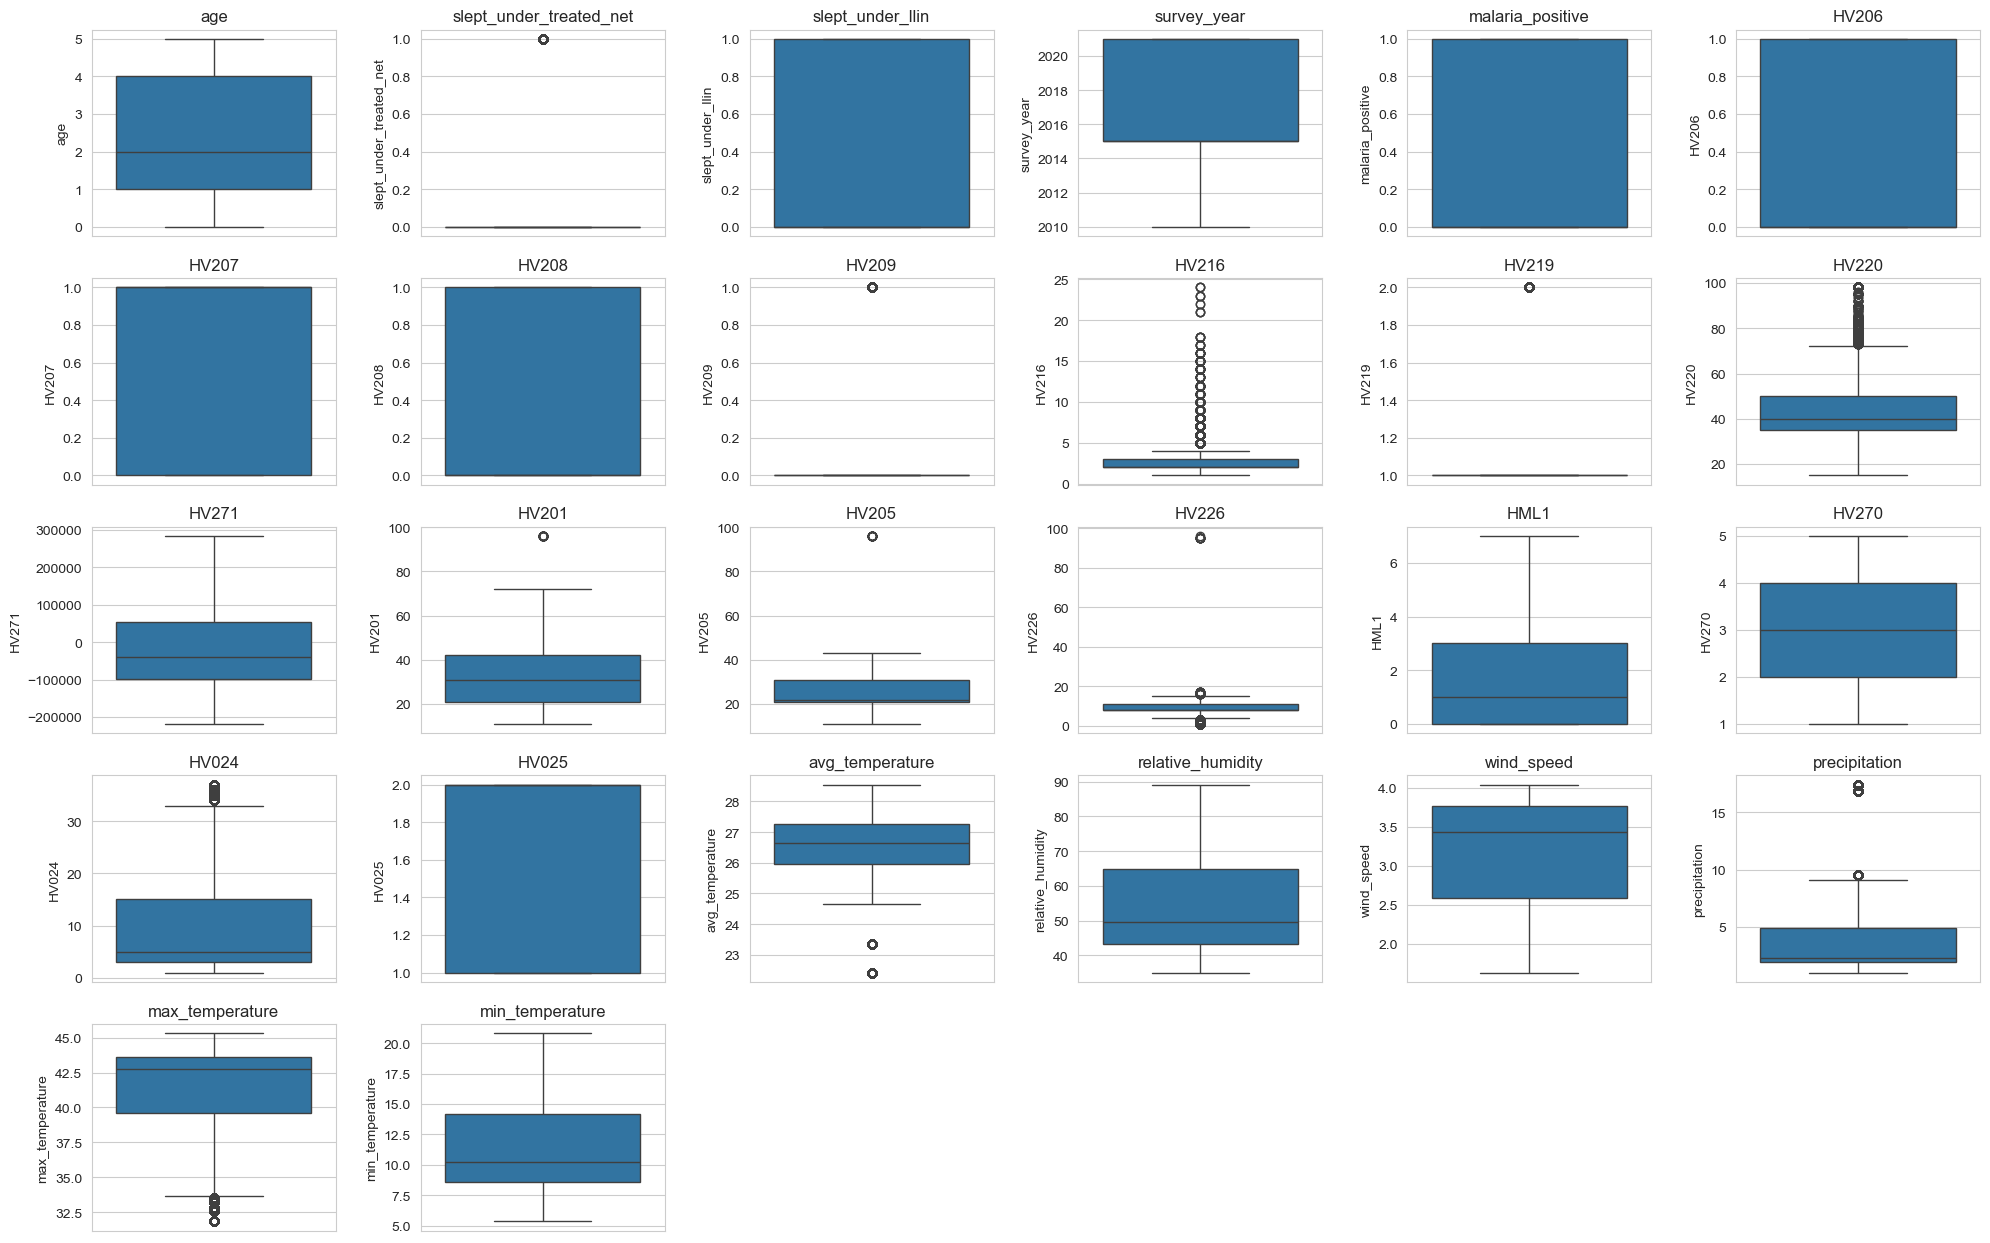

In [23]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,15))

for i, col in enumerate(numeric_cols):
    plt.subplot(6,6,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [24]:
# Calculating outlier percentages

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    percentage = (len(outliers)/len(df))*100

    print(col)
    print('Outliers:', len(outliers))
    print('Percentage:', round(percentage,2))
    print('----------------')

age
Outliers: 0
Percentage: 0.0
----------------
slept_under_treated_net
Outliers: 3958
Percentage: 18.37
----------------
slept_under_llin
Outliers: 0
Percentage: 0.0
----------------
survey_year
Outliers: 0
Percentage: 0.0
----------------
malaria_positive
Outliers: 0
Percentage: 0.0
----------------
HV206
Outliers: 0
Percentage: 0.0
----------------
HV207
Outliers: 0
Percentage: 0.0
----------------
HV208
Outliers: 0
Percentage: 0.0
----------------
HV209
Outliers: 4064
Percentage: 18.86
----------------
HV216
Outliers: 2740
Percentage: 12.72
----------------
HV219
Outliers: 2013
Percentage: 9.34
----------------
HV220
Outliers: 878
Percentage: 4.08
----------------
HV271
Outliers: 0
Percentage: 0.0
----------------
HV201
Outliers: 32
Percentage: 0.15
----------------
HV205
Outliers: 21
Percentage: 0.1
----------------
HV226
Outliers: 1999
Percentage: 9.28
----------------
HML1
Outliers: 0
Percentage: 0.0
----------------
HV270
Outliers: 0
Percentage: 0.0
----------------
HV024
Outl

In [12]:
pd.crosstab(
    df['HV025'],
    df['malaria_positive'],
    normalize='index'
)

malaria_positive,0,1
HV025,,
1,0.862887,0.137113
2,0.674638,0.325362


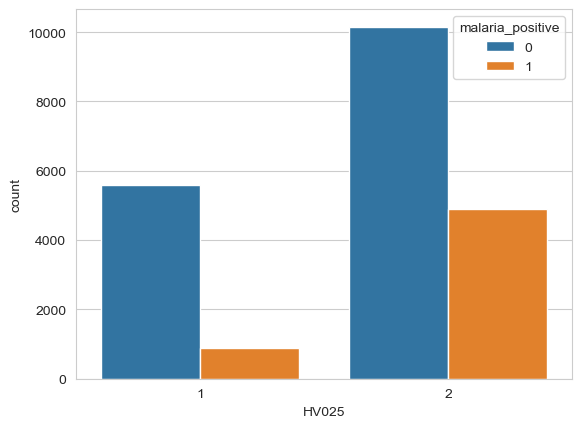

In [13]:
sns.countplot(
    data=df,
    x='HV025',
    hue='malaria_positive'
)
plt.show()

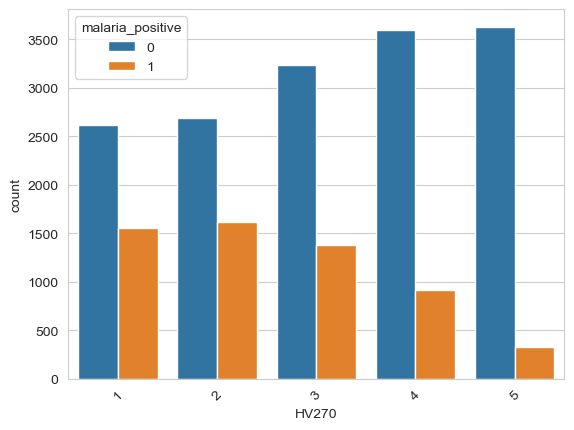

In [16]:
sns.countplot(
    data=df,
    x='HV270',
    hue='malaria_positive'
)
plt.xticks(rotation=45)
plt.show()

In [17]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(21545, 36)
['HHID', 'HV001', 'HV002', 'person_no', 'age', 'slept_under_treated_net', 'slept_under_llin', 'blood_smear_result', 'rapid_test_result', 'pfalciparum', 'pmalariae', 'survey_year', 'malaria_positive', 'HV005', 'HV206', 'HV207', 'HV208', 'HV209', 'HV216', 'HV219', 'HV220', 'HV271', 'HV201', 'HV205', 'HV226', 'HML1', 'HV270', 'HV024', 'HV025', 'state', 'avg_temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'max_temperature', 'min_temperature']
        HHID  HV001  HV002  person_no  age  slept_under_treated_net  \
0       2 23      2     23          2    3                        0   
1       2 24      2     24          2    4                        1   
2       4  3      4      3          2    4                        0   
3       4 20      4     20          2    2                        0   
4       6  7      6      7          2    1                        0   

   slept_under_llin  blood_smear_result  rapid_test_result  pfalciparum  \
0                 0      

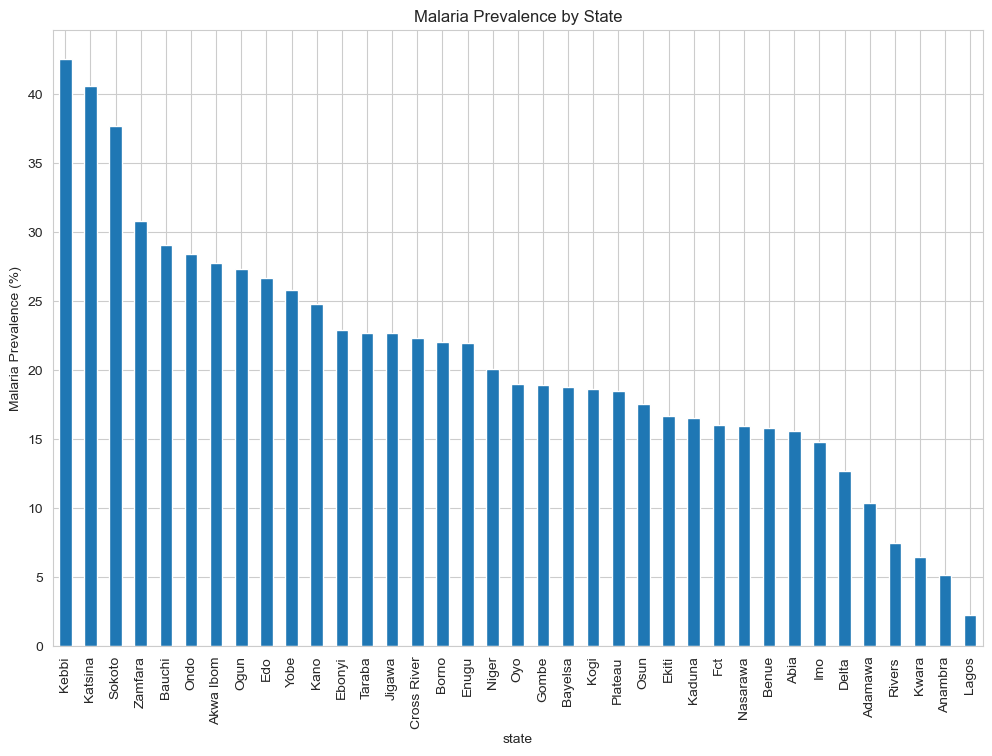

In [30]:
# Malaria positive by states
state_malaria = (
    df.groupby('state')['malaria_positive']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(12,8))

state_malaria.plot(
    kind='bar'
)

plt.ylabel('Malaria Prevalence (%)')
plt.title('Malaria Prevalence by State')

plt.xticks(rotation=90)

plt.show()

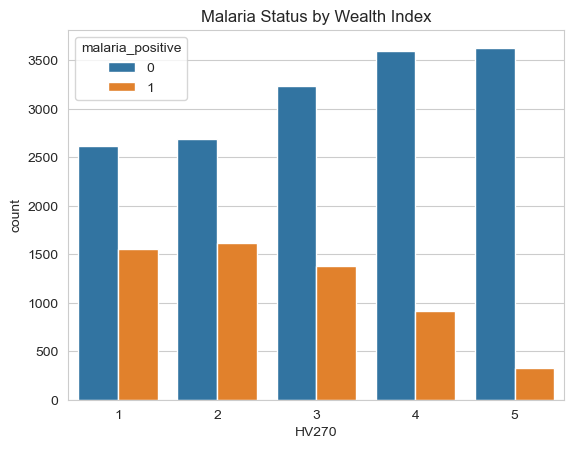

In [31]:
# Malarai positive by wealth index
sns.countplot(
    data=df,
    x='HV270',
    hue='malaria_positive'
)

plt.title('Malaria Status by Wealth Index')

plt.show()

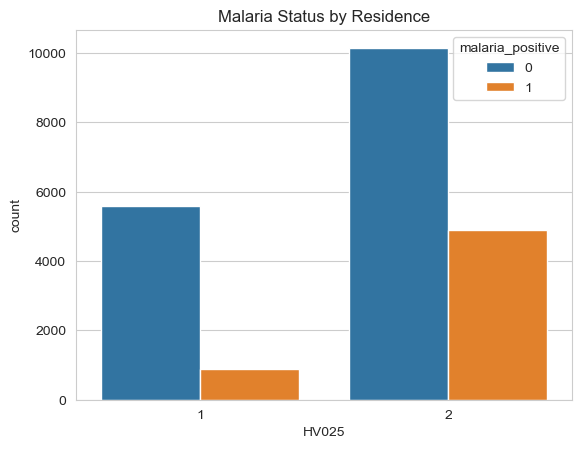

In [32]:
# Malaria positive by residence
sns.countplot(
    data=df,
    x='HV025',
    hue='malaria_positive'
)

plt.title('Malaria Status by Residence')

plt.show()

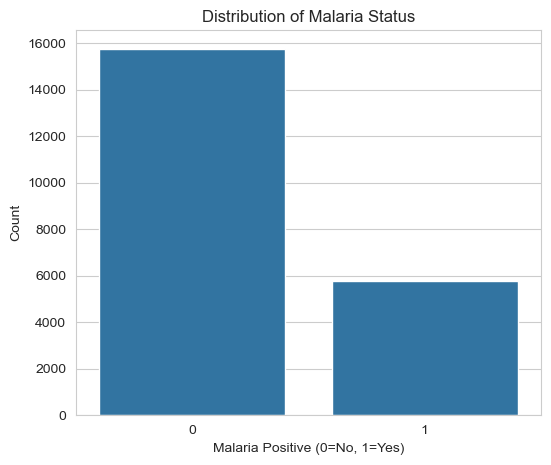

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x=target
)

plt.title('Distribution of Malaria Status')
plt.xlabel('Malaria Positive (0=No, 1=Yes)')
plt.ylabel('Count')

plt.show()

# Nature of each of the variables in the model
Demographic:
[age
state
wealth (HV271)
education (HV106 if available)
electricity (HV206)
radio (HV207)
television (HV208)]


Environmental:
[avg_temperature
relative_humidity
precipitation
wind_speed
max_temperature
min_temperature]


Behavioural:
[slept_under_treated_net
slept_under_llin]


Target:
[malaria_positive]

In [26]:
df.to_csv(
    'modeling_data.csv',
    index=False
)